# RL-guided super-resolution with radiometric consistency

**CSE 753 project.** Does a reward that includes NDVI accuracy produce super-resolved
output that preserves downstream scientific accuracy better than a reward based on pixel
fidelity alone, even at equal or lower PSNR?

Data: [SEN2VEN&mu;S](https://doi.org/10.5281/zenodo.6514159) (Zenodo 6514159), single site.

| Section | Contents |
|---|---|
| 0 | Setup: imports, seed, config, paths |
| 1 | Data loading: `.pt` loading, reflectance scaling, NDVI helper, pair-level split |
| 2 | Phase 0: sanity checks |
| 3 | Metrics + `evaluate()` |
| 4 | SRCNN |
| 5 | Phase 1 results |
| 6 | RL environment |
| 7 | Q-learning training (two reward variants) |
| 8 | Final comparison |
| 9 | Conclusion |

## 0. Setup

Everything configurable lives in `CFG`. No magic numbers anywhere else.

In [1]:
import os, sys, json, time, random, hashlib, platform
from collections import OrderedDict
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats as sps
from skimage.metrics import structural_similarity as sk_ssim

PROJECT_ROOT = os.path.abspath(os.getcwd())

CFG = {
    # --- data ---------------------------------------------------------
    "site":            "NARYN",          # "NARYN" or "FR-LQ1"
    "data_root":       PROJECT_ROOT,     # folder that CONTAINS the site folders
    "results_dir":     os.path.join(PROJECT_ROOT, "results"),
    "bands":           ["B2", "B3", "B4", "B8"],   # channel order in the .pt files
    "idx_red":         2,                # channel index of red  (B4)
    "idx_nir":         3,                # channel index of NIR  (B8)
    "idx_rgb":         (2, 1, 0),        # (R, G, B) = (B4, B3, B2) for display
    "reflectance_scale": 10000.0,        # int16 -> float surface reflectance
    "upscale":         2,                # 10 m (128px) -> 5 m (256px)
    "lr_size":         128,
    "hr_size":         256,

    # --- reproducibility ---------------------------------------------
    "seed":            753,
    # train / val / test BY ACQUISITION PAIR. Widened from the nominal 70/15/15 to
    # 64/16/20 after Phase 0: 25 pairs -> 16/4/5, so the headline claim rests on five
    # independent acquisition dates instead of three.
    "split_fracs":     (0.64, 0.16, 0.20),

    # --- quality screening ---------------------------------------------
    # Phase 0 verdict: NO patch filtering. Negative reflectance concentrates in dark,
    # densely-vegetated and shadowed pixels -- the exact high-NDVI regime this project
    # is about -- so dropping those patches would delete the evidence. The NDVI clip
    # handles the divide-by-near-zero pixels (see 2.3b). Thresholds kept for reporting.
    "nodata_value":    -10000,           # sentinel: ZERO occurrences in NARYN
    "saturation_dn":   10000,            # DN above this == reflectance > 1.0
    "extreme_dn":      20000,            # DN above this == reflectance > 2.0
    "filter_patches":  False,            # decided 2026-08-12: stays off

    # --- NDVI ---------------------------------------------------------
    "ndvi_eps":        1e-8,
    "ndvi_clip":       (-1.0, 1.0),

    # --- metrics (Phase 1) -------------------------------------------
    # PSNR/SSIM are computed on FLOAT REFLECTANCE with a FIXED data range of 1.0
    # (i.e. 0-100% reflectance), not on a per-patch min-max stretch. Fixed, because a
    # per-patch range would make PSNR incomparable between patches -- which is the very
    # thing the Phase 1 scatter plot compares.
    "psnr_data_range": 1.0,
    "ssim_gaussian":   True,             # Wang et al. settings: gaussian window,
    "ssim_sigma":      1.5,              # sigma 1.5, no sample-covariance correction
    # SR output is NOT clamped to [0,1]: HR itself contains slightly negative reflectance
    # (see 2.2/2.3b), so clamping would penalise a model for reproducing the truth.
    "clamp_sr":        False,

    # --- SRCNN (Phase 1) ---------------------------------------------
    "srcnn_epochs":    20,
    "srcnn_batch":     16,
    "srcnn_lr":        1e-3,   # 1e-4 was too slow: val never beat epoch 1
    "srcnn_features":  (64, 32),         # classic SRCNN 9-5-5 widths
    "srcnn_loss":      "l1",             # "l1" or "mse", on reflectance
    "srcnn_residual":  True,             # predict a correction to bicubic, not the image
    "srcnn_augment":   True,             # d4 flips/rotations

    # --- RL (Phase 2): tabular Q-learning ------------------------------
    "rl_lambda":       1.0,      # weight on the NDVI term in the shaped reward
    "rl_n_patches":    2478,     # training patches (all of them)
    "rl_epochs":       6,        # passes over those patches
    "rl_crop":         64,       # crop size used during training
    "rl_steps":        4,        # actions taken per episode (episode length T)
    "rl_alpha":        0.10,     # TD learning rate
    "rl_gamma":        0.90,     # discount factor
    "rl_eps_start":    0.90,     # epsilon-greedy exploration, start
    "rl_eps_end":      0.05,     # ... and end (linear decay)
    "rl_batch":        32,       # episodes processed together (pure speed, not algorithmic)
    # Actions are ADAPTIVE (proportional to the local residual), not fixed offsets.
    # A fixed +-delta has expected squared-error change of +delta^2 whenever the
    # state cannot predict the error sign -- i.e. it can only ever lose.
    "rl_sharp_weak":   0.25,
    "rl_sharp_strong": 0.75,
    # Reward components are NORMALISED to unit spread at runtime (see section 6), so
    # rl_lambda is a genuine relative weight. A fixed scale here was 465x off.
    "rl_grad_bins":    (0.004, 0.012, 0.030),   # edges for the local-detail feature
    "rl_res_bins":     (-0.015, 0.015),  # NDVI minus local-mean NDVI: the sign of
                                         # this is what tells the agent WHICH WAY
                                         # bicubic over-smoothed the pixel
    "rl_ndvi_bins":    (0.25, 0.50, 0.70, 0.85),  # edges for the NDVI state feature

    # --- runtime ------------------------------------------------------
    "cache_max_pairs": 4,                # acquisition pairs held in RAM at once
    "device":          "cuda" if torch.cuda.is_available() else "cpu",
}

CFG["site_dir"]  = os.path.join(CFG["data_root"], CFG["site"])
CFG["cache_dir"] = os.path.join(CFG["results_dir"], "cache")
CFG["fig_dir"]   = os.path.join(CFG["results_dir"], "figures")
for _d in (CFG["results_dir"], CFG["cache_dir"], CFG["fig_dir"]):
    os.makedirs(_d, exist_ok=True)

In [2]:
def set_seed(seed):
    """Seed every RNG we touch. Called once here, and again before each training run."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG["seed"])

def stamp():
    """Timestamp for output filenames. Results are never overwritten."""
    return datetime.now().strftime("%Y%m%d-%H%M%S")

def out_path(name, subdir=None):
    """results/<subdir>/<stem>_<timestamp><ext>"""
    stem, ext = os.path.splitext(name)
    d = CFG["fig_dir"] if subdir == "fig" else CFG["results_dir"]
    return os.path.join(d, f"{stem}_{stamp()}{ext}")

def cache_path(name):
    """Deterministic (site-keyed, NOT timestamped) path for expensive intermediates
    that later cells reload instead of recomputing."""
    stem, ext = os.path.splitext(name)
    return os.path.join(CFG["cache_dir"], f"{stem}__{CFG['site']}{ext}")

print(f"python {platform.python_version()} | torch {torch.__version__} | device {CFG['device']}")
if CFG["device"] == "cuda":
    print(f"gpu    {torch.cuda.get_device_name(0)}")
print(f"seed   {CFG['seed']}")
print(f"site   {CFG['site']}  ->  {CFG['site_dir']}")
print(f"out    {CFG['results_dir']}")

python 3.12.6 | torch 2.10.0+cu126 | device cuda
gpu    NVIDIA GeForce RTX 4070 Laptop GPU
seed   753
site   NARYN  ->  E:\CSE753_project\NARYN
out    E:\CSE753_project\results


## 1. Data loading

**Format facts, verified against the files on disk (see Phase 0 &sect;2.1):**

* Files are `torch.save`d tensors, loaded with `torch.load` &mdash; not GeoTIFF.
* Shape `[n, c, h, w]`, `c = 4`, `dtype = int16`.
* `{id}_10m_b2b3b4b8.pt` &rarr; LR input, `128x128`, Sentinel-2.
* `{id}_05m_b2b3b4b8.pt` &rarr; HR target, `256x256`, VEN&mu;S. So this is x2 SR.
* Divide by `10000` for float surface reflectance **before** any NDVI computation.
* Band order `B2, B3, B4, B8`; red = channel 2, NIR = channel 3.
* `index.csv` is tab-separated, one row per acquisition pair.

**Splitting rule:** hold out *entire acquisition pairs*, never random patches. Patches from
one date are strongly spatially and radiometrically correlated; a random patch split leaks
the test set into training and inflates every metric.

The split is written to JSON and is authoritative &mdash; `make_split` *raises* rather than
re-splitting if `seed` or `split_fracs` drift away from what the file was built from. Every
cached metric downstream carries `SPLIT_HASH` in its filename, so a deliberate re-split can
never be read back against stale numbers.

Fractions are 64/16/20 rather than the nominal 70/15/15: with 25 pairs that gives
**16/4/5**, so the headline Phase 1 claim rests on five independent acquisition dates
instead of three.

In [3]:
def read_pair_index(site=None):
    """One row per acquisition pair. index.csv is TAB separated despite the name."""
    site = site or CFG["site"]
    path = os.path.join(CFG["data_root"], site, "index.csv")
    df = pd.read_csv(path, sep="\t")
    df = df.rename(columns={"tensor_10m_b2b3b4b8": "lr_file",
                            "tensor_05m_b2b3b4b8": "hr_file"})
    df["pair_id"] = df["date"].astype(str)
    df = df.sort_values("pair_id").reset_index(drop=True)
    return df[["pair_id", "date", "lr_file", "hr_file", "nb_patches",
               "s2_tile", "venus_zenith_angle"]]

def build_patch_index(pairs=None):
    """Flat table: one row per PATCH, carrying its parent pair. This is the unit that
    metrics are reported over; `pair_id` is the unit that the split is made over."""
    pairs = read_pair_index() if pairs is None else pairs
    rows = []
    for r in pairs.itertuples(index=False):
        for k in range(int(r.nb_patches)):
            rows.append({"pair_id": r.pair_id, "patch_idx": k})
    idx = pd.DataFrame(rows)
    idx["uid"] = idx["pair_id"] + "#" + idx["patch_idx"].astype(str).str.zfill(4)
    return idx.reset_index(drop=True)

PAIRS = read_pair_index()
PATCHES = build_patch_index(PAIRS)
print(f"{CFG['site']}: {len(PAIRS)} acquisition pairs, {len(PATCHES)} patches")
PAIRS

NARYN: 25 acquisition pairs, 3814 patches


,pair_id,date,lr_file,hr_file,nb_patches,s2_tile,venus_zenith_angle
0,2018-04-13,2018-04-13,NARYN_C__43TFG_2018-04-13_10m_b2b3b4b8.pt,NARYN_C__43TFG_2018-04-13_05m_b2b3b4b8.pt,13,43TFG,5.010906
1,2018-06-12,2018-06-12,NARYN_C__43TFG_2018-06-12_10m_b2b3b4b8.pt,NARYN_C__43TFG_2018-06-12_05m_b2b3b4b8.pt,5,43TFG,5.010906
2,2018-06-20,2018-06-20,NARYN_C__43TFG_2018-06-20_10m_b2b3b4b8.pt,NARYN_C__43TFG_2018-06-20_05m_b2b3b4b8.pt,24,43TFG,5.010906
3,2018-07-12,2018-07-12,NARYN_C__43TFG_2018-07-12_10m_b2b3b4b8.pt,NARYN_C__43TFG_2018-07-12_05m_b2b3b4b8.pt,4,43TFG,5.010906
4,2018-07-20,2018-07-20,NARYN_C__43TFG_2018-07-20_10m_b2b3b4b8.pt,NARYN_C__43TFG_2018-07-20_05m_b2b3b4b8.pt,240,43TFG,5.010906
5,2018-08-09,2018-08-09,NARYN_C__43TFG_2018-08-09_10m_b2b3b4b8.pt,NARYN_C__43TFG_2018-08-09_05m_b2b3b4b8.pt,212,43TFG,5.010906
6,2018-08-29,2018-08-29,NARYN_C__43TFG_2018-08-29_10m_b2b3b4b8.pt,NARYN_C__43TFG_2018-08-29_05m_b2b3b4b8.pt,145,43TFG,5.010906
7,2018-09-08,2018-09-08,NARYN_C__43TFG_2018-09-08_10m_b2b3b4b8.pt,NARYN_C__43TFG_2018-09-08_05m_b2b3b4b8.pt,379,43TFG,5.010906
8,2018-10-10,2018-10-10,NARYN_C__43TFG_2018-10-10_10m_b2b3b4b8.pt,NARYN_C__43TFG_2018-10-10_05m_b2b3b4b8.pt,41,43TFG,5.010906
9,2019-05-06,2019-05-06,NARYN_C__43TFG_2019-05-06_10m_b2b3b4b8.pt,NARYN_C__43TFG_2019-05-06_05m_b2b3b4b8.pt,302,43TFG,5.010906


In [4]:
_PAIR_CACHE = OrderedDict()   # pair_id -> (lr_int16, hr_int16); LRU, bounded by CFG

def load_pair_raw(pair_id):
    """Load the int16 tensors for one acquisition pair, with an LRU cache so that
    iterating patch-by-patch does not re-read the file every time."""
    if pair_id in _PAIR_CACHE:
        _PAIR_CACHE.move_to_end(pair_id)
        return _PAIR_CACHE[pair_id]
    row = PAIRS.loc[PAIRS.pair_id == pair_id].iloc[0]
    lr = torch.load(os.path.join(CFG["site_dir"], row.lr_file), map_location="cpu")
    hr = torch.load(os.path.join(CFG["site_dir"], row.hr_file), map_location="cpu")
    assert lr.dtype == torch.int16 and hr.dtype == torch.int16, "expected int16 on disk"
    assert lr.shape[0] == hr.shape[0] == int(row.nb_patches), \
        f"{pair_id}: n mismatch {lr.shape[0]}/{hr.shape[0]} vs index {row.nb_patches}"
    assert lr.shape[1] == hr.shape[1] == len(CFG["bands"])
    assert lr.shape[-1] == CFG["lr_size"] and hr.shape[-1] == CFG["hr_size"]
    _PAIR_CACHE[pair_id] = (lr, hr)
    while len(_PAIR_CACHE) > CFG["cache_max_pairs"]:
        _PAIR_CACHE.popitem(last=False)
    return lr, hr

def to_reflectance(x):
    """int16 DN -> float32 surface reflectance. Everything downstream assumes this
    has already been applied."""
    return x.to(torch.float32) / CFG["reflectance_scale"]

def get_patch(pair_id, patch_idx, reflectance=True):
    """(lr, hr) for a single patch, shapes [4,128,128] and [4,256,256]."""
    lr, hr = load_pair_raw(pair_id)
    lr, hr = lr[patch_idx], hr[patch_idx]
    return (to_reflectance(lr), to_reflectance(hr)) if reflectance else (lr, hr)

In [5]:
def ndvi(x, eps=None, clip=True):
    """NDVI from FLOAT REFLECTANCE. Accepts [...,C,H,W]; C indexed by CFG.
    Returns [...,H,W]."""
    assert x.dtype.is_floating_point, "ndvi() expects float reflectance, not int16 DN"
    eps = CFG["ndvi_eps"] if eps is None else eps
    red = x[..., CFG["idx_red"], :, :]
    nir = x[..., CFG["idx_nir"], :, :]
    v = (nir - red) / (nir + red + eps)
    return v.clamp(*CFG["ndvi_clip"]) if clip else v

def bicubic_up(x, factor=None):
    """Bicubic upsample on reflectance. Accepts [C,H,W] or [N,C,H,W]."""
    factor = CFG["upscale"] if factor is None else factor
    squeeze = (x.dim() == 3)
    if squeeze:
        x = x.unsqueeze(0)
    y = F.interpolate(x, scale_factor=factor, mode="bicubic", align_corners=False)
    return y.squeeze(0) if squeeze else y

def rgb_stretch(x, lo=2, hi=98, ref=None):
    """[C,H,W] reflectance -> [H,W,3] uint8-ish float for display. Percentiles are
    taken from `ref` when given so LR and HR share one stretch."""
    img = x[list(CFG["idx_rgb"])].permute(1, 2, 0).numpy()
    src = img if ref is None else ref[list(CFG["idx_rgb"])].permute(1, 2, 0).numpy()
    p_lo, p_hi = np.percentile(src, lo), np.percentile(src, hi)
    return np.clip((img - p_lo) / max(p_hi - p_lo, 1e-8), 0, 1)

In [6]:
def make_split(force=False):
    """Split BY ACQUISITION PAIR, seeded, persisted to JSON.

    Pairs are shuffled with a dedicated RNG (not the global one) so the split does not
    depend on how many random numbers earlier cells happened to consume.

    The JSON is authoritative: it is never silently regenerated. If CFG['seed'] or
    CFG['split_fracs'] no longer match what the file was built from, this raises rather
    than quietly re-splitting under you -- re-split deliberately with force=True."""
    path = cache_path("split.json")
    if os.path.exists(path) and not force:
        with open(path) as f:
            split = json.load(f)
        drift = []
        if set(sum(split["pairs"].values(), [])) != set(PAIRS.pair_id):
            drift.append("the set of pairs on disk changed")
        if split.get("seed") != CFG["seed"]:
            drift.append(f"seed {split.get('seed')} -> {CFG['seed']}")
        if tuple(split.get("split_fracs", ())) != tuple(CFG["split_fracs"]):
            drift.append(f"fracs {tuple(split.get('split_fracs', ()))} -> {tuple(CFG['split_fracs'])}")
        if drift:
            raise RuntimeError(
                f"{path}\nwas built under different settings ({'; '.join(drift)}).\n"
                "Refusing to re-split silently -- every cached metric downstream is keyed "
                "to this split.\nRun  make_split(force=True)  to re-split deliberately.")
        return split

    ids = sorted(PAIRS.pair_id.tolist())
    rng = np.random.default_rng(CFG["seed"])
    order = rng.permutation(len(ids))
    ids = [ids[i] for i in order]
    n = len(ids)
    n_tr = int(round(CFG["split_fracs"][0] * n))
    n_va = int(round(CFG["split_fracs"][1] * n))
    n_va = max(1, min(n_va, n - n_tr - 1))
    split = {"site": CFG["site"], "seed": CFG["seed"], "unit": "acquisition_pair",
             "split_fracs": list(CFG["split_fracs"]),
             "created": datetime.now().isoformat(timespec="seconds"),
             "pairs": {"train": sorted(ids[:n_tr]),
                       "val":   sorted(ids[n_tr:n_tr + n_va]),
                       "test":  sorted(ids[n_tr + n_va:])}}
    with open(path, "w") as f:
        json.dump(split, f, indent=2)
    return split

SPLIT = make_split()

# Fingerprint of the actual pair assignment. Every cached metric below carries it in its
# filename, so a re-split can never be read back against stale numbers.
SPLIT_HASH = hashlib.md5(json.dumps(SPLIT["pairs"], sort_keys=True).encode()).hexdigest()[:8]

def patches_in(split_name):
    """Patch-index rows belonging to one split."""
    return PATCHES[PATCHES.pair_id.isin(SPLIT["pairs"][split_name])].reset_index(drop=True)

for name in ("train", "val", "test"):
    ps, np_ = SPLIT["pairs"][name], len(patches_in(name))
    print(f"{name:5s}  {len(ps):2d} pairs  {np_:5d} patches  ({np_/len(PATCHES):5.1%})")
    print(f"        {', '.join(ps)}")
print(f"\nsplit {SPLIT_HASH} -> {cache_path('split.json')}")

train  16 pairs   2478 patches  (65.0%)
        2018-04-13, 2018-06-12, 2018-08-09, 2018-08-29, 2018-09-08, 2019-07-05, 2019-07-25, 2019-07-27, 2019-08-04, 2019-09-03, 2019-11-04, 2019-11-12, 2020-07-31, 2020-08-28, 2020-09-07, 2020-09-17
val     4 pairs    442 patches  (11.6%)
        2018-07-12, 2018-10-10, 2019-05-06, 2019-07-15
test    5 pairs    894 patches  (23.4%)
        2018-06-20, 2018-07-20, 2019-05-28, 2020-05-12, 2020-08-08

split 5f109c79 -> E:\CSE753_project\results\cache\split__NARYN.json


## 2. Phase 0 &mdash; sanity checks

Four questions, answered before any model is trained:

1. Do the tensors have the shape, dtype and value range the format spec claims?
2. How many patches carry nodata / saturated / negative reflectance? Do we filter?
3. **Does NDVI from bicubic-upsampled LR differ measurably from NDVI from HR?**
   If it does not, the project premise has no signal at this site.
4. Are the LR/HR pairs well enough registered to compare per-pixel?

### 2.1 Format and value range on one pair

In [7]:
probe_pair = PAIRS.sort_values("nb_patches").iloc[len(PAIRS) // 2].pair_id
lr_raw, hr_raw = load_pair_raw(probe_pair)

print(f"acquisition pair: {probe_pair}\n")
hdr = f"{'':16s} {'shape':>22s} {'dtype':>14s} {'min':>10s} {'max':>10s} {'mean':>10s}"
print(hdr); print("-" * len(hdr))
for tag, t in [("LR 10m (raw DN)", lr_raw), ("HR 05m (raw DN)", hr_raw)]:
    print(f"{tag:16s} {str(tuple(t.shape)):>22s} {str(t.dtype):>14s} "
          f"{t.min().item():10.0f} {t.max().item():10.0f} {t.float().mean().item():10.1f}")
for tag, t in [("LR (reflectance)", to_reflectance(lr_raw)), ("HR (reflectance)", to_reflectance(hr_raw))]:
    print(f"{tag:16s} {str(tuple(t.shape)):>22s} {str(t.dtype):>14s} "
          f"{t.min().item():10.4f} {t.max().item():10.4f} {t.mean().item():10.4f}")

print(f"\nper-band reflectance ranges (HR), band order = {CFG['bands']}")
for c, b in enumerate(CFG["bands"]):
    v = to_reflectance(hr_raw[:, c])
    print(f"  ch{c} {b:3s}  min {v.min():8.4f}  p1 {v.quantile(0.01):7.4f}  "
          f"median {v.median():7.4f}  p99 {v.quantile(0.99):7.4f}  max {v.max():8.4f}")
print(f"\nupscale factor {hr_raw.shape[-1] // lr_raw.shape[-1]}x "
      f"({lr_raw.shape[-1]}px @10m -> {hr_raw.shape[-1]}px @5m)")

acquisition pair: 2020-09-17



                                  shape          dtype        min        max       mean
---------------------------------------------------------------------------------------


LR 10m (raw DN)      (144, 4, 128, 128)    torch.int16       -109       6183     1060.9
HR 05m (raw DN)      (144, 4, 256, 256)    torch.int16       -102      10232     1060.9
LR (reflectance)     (144, 4, 128, 128)  torch.float32    -0.0109     0.6183     0.1061
HR (reflectance)     (144, 4, 256, 256)  torch.float32    -0.0102     1.0232     0.1061

per-band reflectance ranges (HR), band order = ['B2', 'B3', 'B4', 'B8']


  ch0 B2   min  -0.0033  p1  0.0068  median  0.0426  p99  0.1297  max   0.7253


  ch1 B3   min  -0.0025  p1  0.0131  median  0.0668  p99  0.1836  max   0.8537


  ch2 B4   min  -0.0041  p1  0.0101  median  0.0786  p99  0.2380  max   0.9669


  ch3 B8   min  -0.0102  p1  0.0497  median  0.2186  p99  0.3656  max   1.0232

upscale factor 2x (128px @10m -> 256px @5m)


### 2.2 How much of the archive is unusable?

Counted over **every patch of every pair** (a few GB of reads, so the result is cached to
`results/cache/`; re-running the cell reloads it). A patch is flagged if *any* pixel in
*either* member of the pair trips the test.

In [8]:
def audit_quality(force=False):
    path = cache_path("phase0_quality.csv")
    if os.path.exists(path) and not force:
        return pd.read_csv(path)
    rows = []
    for pid in PAIRS.pair_id:
        lr, hr = load_pair_raw(pid)
        for k in range(lr.shape[0]):
            r = {"pair_id": pid, "patch_idx": k}
            for tag, t in (("lr", lr[k]), ("hr", hr[k])):
                t = t.to(torch.int32)
                r[f"{tag}_n_nodata"]  = int((t == CFG["nodata_value"]).sum())
                r[f"{tag}_n_neg"]     = int((t < 0).sum())
                r[f"{tag}_n_sat"]     = int((t > CFG["saturation_dn"]).sum())
                r[f"{tag}_n_extreme"] = int((t > CFG["extreme_dn"]).sum())
                r[f"{tag}_min"] = int(t.min()); r[f"{tag}_max"] = int(t.max())
            rows.append(r)
    q = pd.DataFrame(rows)
    for k in ("nodata", "neg", "sat", "extreme"):
        q[f"n_{k}"] = q[f"lr_n_{k}"] + q[f"hr_n_{k}"]
    q.to_csv(path, index=False)
    return q

QUAL = audit_quality()
n_px = len(CFG["bands"]) * (CFG["lr_size"] ** 2 + CFG["hr_size"] ** 2)
print(f"{len(QUAL)} patches audited ({n_px} pixel-band values each)\n")
print(f"{'flag':12s} {'patches affected':>17s} {'frac patches':>13s} {'frac pixels':>12s}")
print("-" * 58)
for k, lbl in [("nodata", f"== {CFG['nodata_value']}"), ("neg", "< 0"),
               ("sat", f"> {CFG['saturation_dn']} DN"), ("extreme", f"> {CFG['extreme_dn']} DN")]:
    aff = int((QUAL[f"n_{k}"] > 0).sum())
    print(f"{lbl:12s} {aff:17d} {aff/len(QUAL):13.2%} "
          f"{QUAL[f'n_{k}'].sum()/(len(QUAL)*n_px):12.4%}")
print(f"\nglobal DN range: LR [{QUAL.lr_min.min()}, {QUAL.lr_max.max()}]  "
      f"HR [{QUAL.hr_min.min()}, {QUAL.hr_max.max()}]")
print(f"cached -> {cache_path('phase0_quality.csv')}")

3814 patches audited (327680 pixel-band values each)

flag          patches affected  frac patches  frac pixels
----------------------------------------------------------
== -10000                    0         0.00%      0.0000%
< 0                       1080        28.32%      0.0761%
> 10000 DN                   5         0.13%      0.0000%
> 20000 DN                   0         0.00%      0.0000%

global DN range: LR [-190, 8647]  HR [-223, 12488]
cached -> E:\CSE753_project\results\cache\phase0_quality__NARYN.csv


In [9]:
# How severe is the contamination in the patches that are flagged at all?
sev = QUAL[QUAL[["n_neg", "n_sat"]].sum(axis=1) > 0]
print(f"patches with any negative or any >1.0 reflectance: {len(sev)} / {len(QUAL)} "
      f"({len(sev)/len(QUAL):.1%})\n")
if len(sev):
    frac = (sev[["n_neg", "n_sat"]].sum(axis=1) / n_px)
    print("distribution of the affected-pixel fraction WITHIN those patches:")
    for p in (0.5, 0.75, 0.9, 0.99, 1.0):
        print(f"  p{int(p*100):<3d} {frac.quantile(p):8.4%}")
    for thr in (0.001, 0.01, 0.05, 0.10):
        drop = int((frac > thr).sum())
        print(f"  dropping patches with >{thr:5.1%} affected pixels loses "
              f"{drop:5d} patches ({drop/len(QUAL):5.1%} of the archive)")

worst = QUAL.assign(bad=QUAL[["n_neg", "n_sat"]].sum(axis=1)).nlargest(8, "bad")
print("\nworst patches:")
print(worst[["pair_id", "patch_idx", "n_neg", "n_sat", "lr_min", "hr_max"]].to_string(index=False))

patches with any negative or any >1.0 reflectance: 1084 / 3814 (28.4%)

distribution of the affected-pixel fraction WITHIN those patches:
  p50   0.0198%
  p75   0.1066%
  p90   0.4773%
  p99   5.7715%
  p100 17.9172%
  dropping patches with > 0.1% affected pixels loses   279 patches ( 7.3% of the archive)
  dropping patches with > 1.0% affected pixels loses    62 patches ( 1.6% of the archive)
  dropping patches with > 5.0% affected pixels loses    12 patches ( 0.3% of the archive)
  dropping patches with >10.0% affected pixels loses     3 patches ( 0.1% of the archive)

worst patches:
   pair_id  patch_idx  n_neg  n_sat  lr_min  hr_max
2019-07-25         21  58711      0     -32    6657
2018-06-20          6  35516      0     -41    6594
2018-06-20         16  33376      0     -42    7341
2019-07-25         13  29792      0     -32    6088
2019-07-25         78  23967      0     -17    5549
2020-09-17         70  22689      0     -79    3777
2019-07-25         88  22470      0     -8

### 2.3 NDVI: HR truth vs bicubic-upsampled LR

This is the cell that decides whether the project has a premise. Both NDVI fields are
computed on **float reflectance** with the same helper; the only difference is whether the
source was the 5&nbsp;m VEN&mu;S image or the bicubically upsampled 10&nbsp;m Sentinel-2 image.

Computed over the **test split only**, so this number is directly comparable to the Phase 1
table later.

In [10]:
def ndvi_compare(split_name="test", force=False, max_patches=None):
    """Per-patch NDVI statistics for HR vs bicubic(LR). Cached."""
    path = cache_path(f"phase0_ndvi_{split_name}_{SPLIT_HASH}.csv")
    if os.path.exists(path) and not force:
        return pd.read_csv(path)
    rows, sub = [], patches_in(split_name)
    if max_patches:
        sub = sub.iloc[:max_patches]
    for r in sub.itertuples(index=False):
        lr, hr = get_patch(r.pair_id, r.patch_idx)
        v_hr, v_bic = ndvi(hr), ndvi(bicubic_up(lr))
        d = v_bic - v_hr
        rows.append({"pair_id": r.pair_id, "patch_idx": r.patch_idx, "uid": r.uid,
                     "ndvi_hr_mean": v_hr.mean().item(), "ndvi_hr_std": v_hr.std().item(),
                     "ndvi_bic_mean": v_bic.mean().item(), "ndvi_bic_std": v_bic.std().item(),
                     "ndvi_mae": d.abs().mean().item(), "ndvi_bias": d.mean().item(),
                     "ndvi_rmse": d.pow(2).mean().sqrt().item(),
                     "ndvi_p95_abs": d.abs().quantile(0.95).item()})
    out = pd.DataFrame(rows)
    out.to_csv(path, index=False)
    return out

NDVI_CMP = ndvi_compare("test")
s = NDVI_CMP
print(f"test split: {len(s)} patches from {s.pair_id.nunique()} acquisition pairs\n")
print(f"  mean NDVI  HR            {s.ndvi_hr_mean.mean():+.4f}   "
      f"(between-patch sd {s.ndvi_hr_mean.std():.4f})")
print(f"  mean NDVI  bicubic(LR)   {s.ndvi_bic_mean.mean():+.4f}   "
      f"(between-patch sd {s.ndvi_bic_mean.std():.4f})")
print(f"  within-patch NDVI sd HR  {s.ndvi_hr_std.mean():.4f}")
print(f"  within-patch NDVI sd bic {s.ndvi_bic_std.mean():.4f}   "
      f"<- see 2.3b: NOT simply 'smoother'")
print()
print(f"  NDVI MAE  (|bicubic - HR|, per-pixel, averaged)  {s.ndvi_mae.mean():.4f}  "
      f"+/- {s.ndvi_mae.std():.4f}")
print(f"  NDVI bias (signed mean error)                    {s.ndvi_bias.mean():+.4f}  "
      f"+/- {s.ndvi_bias.std():.4f}")
print(f"  NDVI RMSE                                        {s.ndvi_rmse.mean():.4f}")
print(f"  per-patch p95 |error|                            {s.ndvi_p95_abs.mean():.4f}")
print()
print(f"  MAE as a fraction of the HR NDVI spread: "
      f"{s.ndvi_mae.mean() / s.ndvi_hr_mean.std():.2f}x between-patch, "
      f"{s.ndvi_mae.mean() / s.ndvi_hr_std.mean():.2f}x within-patch")

test split: 894 patches from 5 acquisition pairs

  mean NDVI  HR            +0.5455   (between-patch sd 0.1753)
  mean NDVI  bicubic(LR)   +0.5467   (between-patch sd 0.1762)
  within-patch NDVI sd HR  0.1590
  within-patch NDVI sd bic 0.1628   <- see 2.3b: NOT simply 'smoother'

  NDVI MAE  (|bicubic - HR|, per-pixel, averaged)  0.0273  +/- 0.0139
  NDVI bias (signed mean error)                    +0.0013  +/- 0.0214
  NDVI RMSE                                        0.0381
  per-patch p95 |error|                            0.0705

  MAE as a fraction of the HR NDVI spread: 0.16x between-patch, 0.17x within-patch


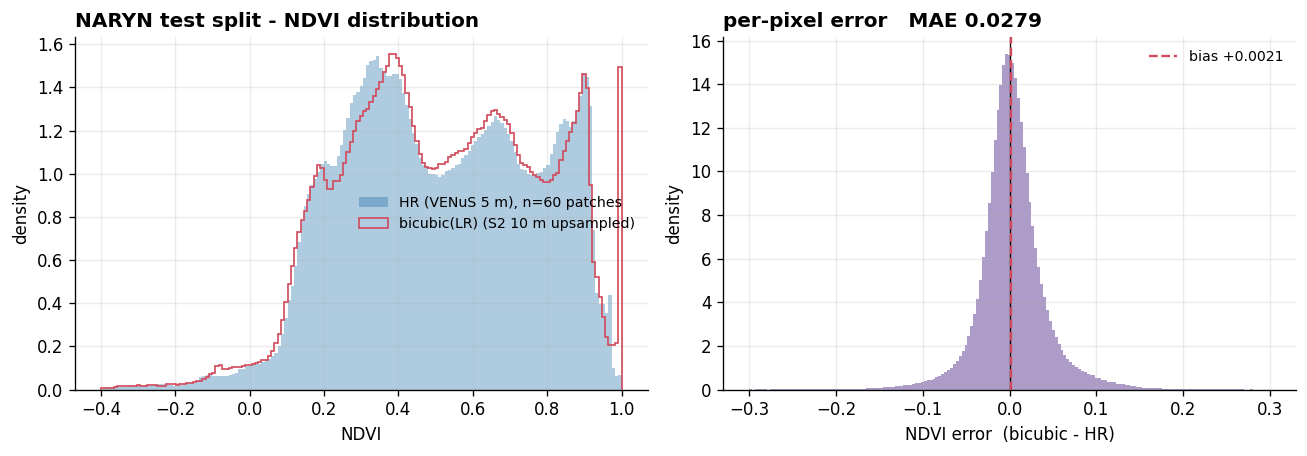

pixels compared: 3,932,160


In [11]:
# --- histogram of the two NDVI distributions on shared axes ---------------------
rng = np.random.default_rng(CFG["seed"])
sample = NDVI_CMP.sample(min(60, len(NDVI_CMP)), random_state=CFG["seed"])
v_hr_all, v_bic_all = [], []
for r in sample.itertuples(index=False):
    lr, hr = get_patch(r.pair_id, int(r.patch_idx))
    v_hr_all.append(ndvi(hr).flatten().numpy())
    v_bic_all.append(ndvi(bicubic_up(lr)).flatten().numpy())
v_hr_all = np.concatenate(v_hr_all); v_bic_all = np.concatenate(v_bic_all)

plt.rcParams.update({"font.size": 10, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight"})
fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
bins = np.linspace(-0.4, 1.0, 160)
ax[0].hist(v_hr_all,  bins=bins, density=True, histtype="stepfilled",
           color="#1b6ca8", alpha=.35, label=f"HR (VENuS 5 m), n={len(sample)} patches")
ax[0].hist(v_bic_all, bins=bins, density=True, histtype="step", lw=1.8,
           color="#d1495b", label="bicubic(LR) (S2 10 m upsampled)")
ax[0].set_xlabel("NDVI"); ax[0].set_ylabel("density")
ax[0].set_title(f"{CFG['site']} test split - NDVI distribution", loc="left", fontweight="bold")
ax[0].legend(frameon=False, fontsize=8.5)

d = v_bic_all - v_hr_all
ax[1].hist(d, bins=np.linspace(-0.3, 0.3, 180), density=True,
           histtype="stepfilled", color="#6b4c9a", alpha=.55)
ax[1].axvline(0, color="k", lw=.8)
ax[1].axvline(d.mean(), color="#d1495b", lw=1.4, ls="--",
              label=f"bias {d.mean():+.4f}")
ax[1].set_xlabel("NDVI error  (bicubic - HR)"); ax[1].set_ylabel("density")
ax[1].set_title(f"per-pixel error   MAE {np.abs(d).mean():.4f}", loc="left", fontweight="bold")
ax[1].legend(frameon=False, fontsize=8.5)
fig.tight_layout()
fig.savefig(out_path("phase0_ndvi_hist.png", "fig"))
plt.show()
print(f"pixels compared: {len(d):,}")

### 2.3b Where the NDVI error actually lives

Two things the summary numbers hide, both of which change how Phase 1 must be read:

1. **NDVI is not bounded in practice.** L2A surface reflectance goes slightly *negative*
   in the red band over dark, densely vegetated and shadowed pixels. When `red < 0` the
   ratio `(nir-red)/(nir+red)` exceeds 1 and can reach O(10). The `clip(-1,1)` in the
   brief is therefore not cosmetic &mdash; it is what keeps the metric finite. This cell
   quantifies how many pixels depend on it.
2. **The error is spatially structured**, not white noise: it concentrates in particular
   brightness and vegetation regimes. That structure is exactly what a PSNR-only objective
   has no reason to fix.

In [12]:
def clip_diagnostic(split_name="test", n_pairs=None):
    rows = []
    pids = SPLIT["pairs"][split_name][:n_pairs] if n_pairs else SPLIT["pairs"][split_name]
    for pid in pids:
        lr_i, hr_i = load_pair_raw(pid)
        lr, hr = to_reflectance(lr_i), to_reflectance(hr_i)
        bic = bicubic_up(lr)
        for tag, x in (("HR", hr), ("bicubic", bic)):
            raw = ndvi(x, clip=False)
            rows.append({"pair_id": pid, "source": tag, "n_px": raw.numel(),
                         "raw_min": raw.min().item(), "raw_max": raw.max().item(),
                         "n_out_of_range": int((raw.abs() > 1).sum()),
                         "n_red_negative": int((x[:, CFG["idx_red"]] < 0).sum()),
                         "n_ndvi_ge_099": int((ndvi(x) > 0.99).sum())})
    d = pd.DataFrame(rows)
    for c in ("n_out_of_range", "n_red_negative", "n_ndvi_ge_099"):
        d[c.replace("n_", "frac_")] = d[c] / d.n_px
    return d

CLIP_DIAG = clip_diagnostic()
agg = CLIP_DIAG.groupby("source").agg(
    raw_min=("raw_min", "min"), raw_max=("raw_max", "max"),
    frac_red_neg=("frac_red_negative", "mean"),
    frac_out_of_range=("frac_out_of_range", "mean"),
    frac_ndvi_saturated=("frac_ndvi_ge_099", "mean"))
print("NDVI computed WITHOUT clipping, over the test split:\n")
print(agg.to_string(float_format=lambda v: f"{v:.4f}"))
print("\n  raw_min/raw_max        : unclipped NDVI extremes -- far outside [-1,1]")
print("  frac_red_neg           : pixels with NEGATIVE red reflectance (L2A artifact)")
print("  frac_out_of_range      : pixels where |NDVI| > 1 before clipping")
print("  frac_ndvi_saturated    : pixels sitting at NDVI > 0.99 after clipping")
print("\nBicubic pushes MORE pixels into the saturated NDVI regime than HR has "
      "\n(frac_ndvi_saturated), which is why its within-patch NDVI sd came out HIGHER "
      "\nthan HR's in 2.3 despite being a spatially smoother image.")

NDVI computed WITHOUT clipping, over the test split:

           raw_min  raw_max  frac_red_neg  frac_out_of_range  frac_ndvi_saturated
source                                                                           
HR        -26.6662  20.3327        0.0096             0.0096               0.0121
bicubic -5402.5664 463.3931        0.0088             0.0090               0.0213

  raw_min/raw_max        : unclipped NDVI extremes -- far outside [-1,1]
  frac_red_neg           : pixels with NEGATIVE red reflectance (L2A artifact)
  frac_out_of_range      : pixels where |NDVI| > 1 before clipping
  frac_ndvi_saturated    : pixels sitting at NDVI > 0.99 after clipping

Bicubic pushes MORE pixels into the saturated NDVI regime than HR has 
(frac_ndvi_saturated), which is why its within-patch NDVI sd came out HIGHER 
than HR's in 2.3 despite being a spatially smoother image.


In [13]:
# Effect of the clip on the headline metric, and where the error concentrates.
pid = SPLIT["pairs"]["test"][0]
lr, hr = (to_reflectance(t) for t in load_pair_raw(pid))
bic = bicubic_up(lr)

print(f"pair {pid} ({hr.shape[0]} patches)\n")
for clip in (True, False):
    d = ndvi(bic, clip=clip) - ndvi(hr, clip=clip)
    print(f"  clip={str(clip):5s}  MAE {d.abs().mean():.4f}  bias {d.mean():+.4f}  "
          f"max|err| {d.abs().max():8.3f}")
print("\n-> the unclipped variant is dominated by a handful of divide-by-near-zero pixels."
      "\n   CFG['ndvi_clip'] stays on for every number in this project.\n")

d = (ndvi(bic) - ndvi(hr)).flatten().numpy()
v = ndvi(hr).flatten().numpy()
bright = hr[:, :3].mean(1).flatten().numpy()
for name, strat, fmt in [("HR NDVI", v, "+.2f"), ("HR visible reflectance", bright, ".3f")]:
    q = np.quantile(strat, np.linspace(0, 1, 6))
    print(f"NDVI error stratified by {name} (quintiles):")
    for i in range(5):
        m = (strat >= q[i]) & (strat < q[i + 1])
        print(f"  [{q[i]:{fmt}}, {q[i+1]:{fmt}})   MAE {np.abs(d[m]).mean():.4f}   "
              f"bias {d[m].mean():+.4f}")
    print()

pair 2018-06-20 (24 patches)

  clip=True   MAE 0.0367  bias +0.0054  max|err|    2.000
  clip=False  MAE 0.0388  bias +0.0038  max|err|   28.245

-> the unclipped variant is dominated by a handful of divide-by-near-zero pixels.
   CFG['ndvi_clip'] stays on for every number in this project.

NDVI error stratified by HR NDVI (quintiles):
  [-1.00, +0.41)   MAE 0.0386   bias +0.0109
  [+0.41, +0.63)   MAE 0.0350   bias +0.0043
  [+0.63, +0.79)   MAE 0.0408   bias +0.0059
  [+0.79, +0.91)   MAE 0.0417   bias +0.0074
  [+0.91, +1.00)   MAE 0.0332   bias +0.0005

NDVI error stratified by HR visible reflectance (quintiles):
  [-0.004, 0.026)   MAE 0.0387   bias +0.0031
  [0.026, 0.039)   MAE 0.0410   bias +0.0123
  [0.039, 0.056)   MAE 0.0364   bias +0.0060
  [0.056, 0.086)   MAE 0.0336   bias +0.0012
  [0.086, 0.914)   MAE 0.0338   bias +0.0043



### 2.4 Registration check &mdash; LR/HR side by side

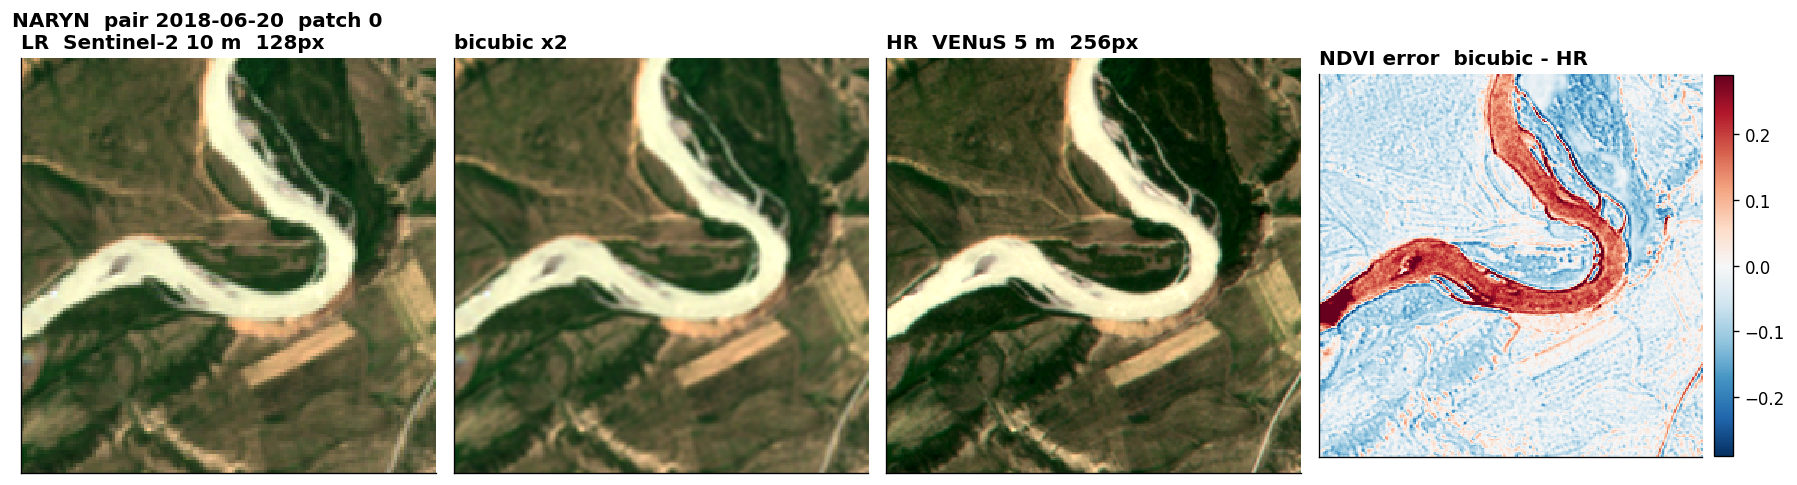

patch NDVI MAE 0.0717   bias -0.0182


In [14]:
# Pick a visually busy test patch (high HR NDVI spread) so misregistration would show.
cand = NDVI_CMP.nlargest(1, "ndvi_hr_std").iloc[0]
lr, hr = get_patch(cand.pair_id, int(cand.patch_idx))
bic = bicubic_up(lr)

fig, ax = plt.subplots(1, 4, figsize=(15, 4.1))
ax[0].imshow(rgb_stretch(lr, ref=hr), interpolation="nearest")
ax[0].set_title(f"LR  Sentinel-2 10 m  {CFG['lr_size']}px", loc="left", fontweight="bold")
ax[1].imshow(rgb_stretch(bic, ref=hr), interpolation="nearest")
ax[1].set_title("bicubic x2", loc="left", fontweight="bold")
ax[2].imshow(rgb_stretch(hr), interpolation="nearest")
ax[2].set_title(f"HR  VENuS 5 m  {CFG['hr_size']}px", loc="left", fontweight="bold")
err = (ndvi(bic) - ndvi(hr)).numpy()
lim = float(np.abs(np.percentile(err, [1, 99])).max())
im = ax[3].imshow(err, cmap="RdBu_r", vmin=-lim, vmax=lim, interpolation="nearest")
ax[3].set_title("NDVI error  bicubic - HR", loc="left", fontweight="bold")
fig.colorbar(im, ax=ax[3], fraction=.046, pad=.03)
for a in ax:
    a.set_xticks([]); a.set_yticks([]); a.grid(False)
fig.suptitle(f"{CFG['site']}  pair {cand.pair_id}  patch {int(cand.patch_idx)}",
             x=.005, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig(out_path("phase0_registration.png", "fig"))
plt.show()
print(f"patch NDVI MAE {cand.ndvi_mae:.4f}   bias {cand.ndvi_bias:+.4f}")

### 2.5 Would the other site behave differently?

The brief allows either site. This runs the &sect;2.3 headline numbers for both so the choice
is made on evidence rather than by default.

In [15]:
def site_headline(site, n_pairs=4, per_pair=25):
    """Cheap cross-site probe: a few pairs, a few patches each. Not a substitute for
    the full test-split numbers above."""
    prev = CFG["site"], CFG["site_dir"]
    CFG["site"], CFG["site_dir"] = site, os.path.join(CFG["data_root"], site)
    try:
        pr = read_pair_index(site)
        pr = pr[pr.nb_patches >= per_pair].sort_values("nb_patches", ascending=False).head(n_pairs)
        mae, bias, hr_mu, hr_sd, bic_sd = [], [], [], [], []
        for r in pr.itertuples(index=False):
            lr = to_reflectance(torch.load(os.path.join(CFG["site_dir"], r.lr_file), map_location="cpu")[:per_pair])
            hr = to_reflectance(torch.load(os.path.join(CFG["site_dir"], r.hr_file), map_location="cpu")[:per_pair])
            v_hr, v_bic = ndvi(hr), ndvi(bicubic_up(lr))
            d = v_bic - v_hr
            mae.append(d.abs().mean().item()); bias.append(d.mean().item())
            hr_mu.append(v_hr.mean().item()); hr_sd.append(v_hr.std().item())
            bic_sd.append(v_bic.std().item())
        return {"site": site, "pairs": len(pr), "patches": len(pr) * per_pair,
                "ndvi_hr_mean": np.mean(hr_mu), "ndvi_hr_sd": np.mean(hr_sd),
                "ndvi_bic_sd": np.mean(bic_sd), "ndvi_mae": np.mean(mae),
                "ndvi_bias": np.mean(bias), "mae_over_sd": np.mean(mae) / np.mean(hr_sd)}
    finally:
        CFG["site"], CFG["site_dir"] = prev

_cmp_path = os.path.join(CFG["cache_dir"], "phase0_site_comparison.csv")
if os.path.exists(_cmp_path):
    SITE_CMP = pd.read_csv(_cmp_path)
else:
    SITE_CMP = pd.DataFrame([site_headline(s) for s in ("NARYN", "FR-LQ1")])
    SITE_CMP.to_csv(_cmp_path, index=False)
_PAIR_CACHE.clear()
print(SITE_CMP.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nmae_over_sd = NDVI MAE divided by the within-patch NDVI sd."
      "\nHigher means bicubic upsampling distorts NDVI more relative to the scene's own"
      "\nvegetation contrast -- i.e. more headroom for the Phase 1/2 argument.")

  site  pairs  patches  ndvi_hr_mean  ndvi_hr_sd  ndvi_bic_sd  ndvi_mae  ndvi_bias  mae_over_sd
 NARYN      4      100        0.4734      0.2037       0.2073    0.0221     0.0021       0.1086
FR-LQ1      4      100        0.7381      0.1504       0.1552    0.0182     0.0008       0.1212

mae_over_sd = NDVI MAE divided by the within-patch NDVI sd.
Higher means bicubic upsampling distorts NDVI more relative to the scene's own
vegetation contrast -- i.e. more headroom for the Phase 1/2 argument.


### Phase 0 verdict

**The premise holds at NARYN. Phase 1 is worth running.**

*Format.* Confirmed as specified: `int16`, `/10000`, band order `B2 B3 B4 B8`, red = ch2,
NIR = ch3, 128 &rarr; 256 px (&times;2). Three corrections to the original spec: the
secondary files are named `b4b5b6b8a` (not `b5b6b7b8a`); the axis order is `[n,c,h,w]`;
and **there is no `-10000` nodata sentinel** &mdash; zero occurrences across all 3814 patches.

*Data quality.* 28.3 % of patches contain at least one negative reflectance value, but only
0.076 % of all pixel-band values are affected, and the median flagged patch is 0.02 %
contaminated. **Decision: no filtering** (`CFG['filter_patches'] = False`). Those negatives
sit in dark, densely-vegetated and shadowed pixels &mdash; the exact high-NDVI regime this
project argues about &mdash; so screening them out would delete the evidence. The NDVI clip,
not patch rejection, is what keeps the metric well-behaved.

*Signal.* Over the 5-pair / 894-patch test split, bicubic-vs-HR NDVI MAE is **0.027**,
about 17 % of the scene's own within-patch NDVI spread (0.159), with a per-patch p95 error
of 0.071 &mdash; comparable to the width of a land-cover class boundary. Not noise.

Two results that matter more than the headline MAE:

1. **Mean bias is +0.0013 but its between-patch sd is 0.0214** &mdash; sixteen times larger.
   Individual scenes are systematically greened or browned; the error only looks unbiased
   after averaging over the whole archive. Aggregate radiometric statistics hide per-scene
   error, which is precisely the failure mode this project is about.
2. **Bicubic inflates the NDVI > 0.99 class from 1.21 % of pixels to 2.13 %** &mdash; a 76 %
   relative over-count of saturated vegetation. A downstream thresholding analysis would be
   measurably wrong, and PSNR cannot see it.

*Registration.* Visually excellent (&sect;2.4) &mdash; channel and field boundaries align
crisply. The NDVI error field is spatially **structured** (bright braided-channel and
field-edge error), not white noise. Structured error is the kind an agent can plausibly
learn to correct.

*Site.* NARYN and FR-LQ1 have similar relative NDVI distortion (MAE/sd 0.109 vs 0.121).
NARYN is chosen for its 25 acquisition pairs vs FR-LQ1's 18, which splits better.

*Split.* 16/4/5 pairs = 2478/442/894 patches. Note the patch shares (65 / 12 / 23 %) drift
from the pair shares (64 / 16 / 20 %) because pairs differ in patch count by two orders of
magnitude (1 to 491). That is inherent to splitting on pairs and is the correct trade:
patch-level balance is not worth leaking correlated patches across the boundary.

**Phase 0 reviewed and confirmed. Next: Phase 1 &mdash; bicubic and SRCNN baselines,
`evaluate()`, and the PSNR-vs-NDVI-error decorrelation analysis.**

## 3. Metrics and `evaluate()`

Four per-patch numbers, all computed on **float reflectance**:

| metric | definition |
|---|---|
| PSNR | `10 log10(D^2 / MSE)` over all 4 bands, fixed `D = CFG['psnr_data_range'] = 1.0` |
| SSIM | Wang et al. (gaussian window, `sigma=1.5`), averaged over the 4 bands, same `D` |
| NDVI MAE | `mean |NDVI(SR) - NDVI(HR)|`, both clipped to `[-1,1]` |
| NDVI bias | `mean (NDVI(SR) - NDVI(HR))` &mdash; signed, so a systematic greening or browning shows |

`evaluate(model, split)` is written **once** and every method goes through it &mdash; bicubic,
SRCNN, and both PPO agents in Phase 2. A model is anything implementing `SRModel`: a
callable mapping a batch of LR reflectance `[N,4,128,128]` to SR reflectance
`[N,4,256,256]`. That constraint is what keeps the final four-way table comparable.

In [16]:
def psnr_per_patch(sr, hr, data_range=None):
    """[N,C,H,W] -> [N]. Fixed data range; see CFG for why it is fixed."""
    D = CFG["psnr_data_range"] if data_range is None else data_range
    mse = (sr - hr).pow(2).mean(dim=(-3, -2, -1)).clamp_min(1e-12)
    return (10.0 * torch.log10(D * D / mse))

def ssim_per_patch(sr, hr, data_range=None):
    """[N,C,H,W] -> [N]. skimage, band-averaged. CPU; this is the slow metric."""
    D = CFG["psnr_data_range"] if data_range is None else data_range
    a = sr.detach().cpu().numpy(); b = hr.detach().cpu().numpy()
    out = np.empty(a.shape[0], dtype=np.float64)
    for i in range(a.shape[0]):
        out[i] = sk_ssim(b[i], a[i], data_range=D, channel_axis=0,
                         gaussian_weights=CFG["ssim_gaussian"], sigma=CFG["ssim_sigma"],
                         use_sample_covariance=not CFG["ssim_gaussian"])
    return torch.from_numpy(out)

def ndvi_errors(sr, hr):
    """[N,C,H,W] -> (mae[N], bias[N], rmse[N]). NDVI clipped, per CFG."""
    d = ndvi(sr) - ndvi(hr)
    dims = (-2, -1)
    return (d.abs().mean(dim=dims), d.mean(dim=dims), d.pow(2).mean(dim=dims).sqrt())

# Sanity: a perfect reconstruction must score exactly right. (PSNR saturates at 120 dB
# rather than inf because MSE is clamped at 1e-12 to keep the log finite.)
_x = to_reflectance(load_pair_raw(SPLIT["pairs"]["test"][0])[1][:4])
assert (psnr_per_patch(_x, _x) > 100).all(), "PSNR of an identical pair must saturate"
assert np.allclose(ssim_per_patch(_x, _x).numpy(), 1.0), "SSIM of an identical pair must be 1"
_m, _b, _r = ndvi_errors(_x, _x)
assert _m.abs().max() == 0 and _b.abs().max() == 0, "NDVI error of an identical pair must be 0"
# and degrading the input must move every metric the right way
_y = _x + 0.02 * torch.randn_like(_x)
assert psnr_per_patch(_y, _x).mean() < 40 and ssim_per_patch(_y, _x).mean() < 1
assert ndvi_errors(_y, _x)[0].mean() > 0
print("metric self-check passed: identity -> PSNR 120 dB, SSIM 1.000, NDVI err 0")
print(f"                         +2% noise -> PSNR {psnr_per_patch(_y,_x).mean():.2f} dB, "
      f"SSIM {ssim_per_patch(_y,_x).mean():.4f}, NDVI MAE {ndvi_errors(_y,_x)[0].mean():.4f}")

metric self-check passed: identity -> PSNR 120 dB, SSIM 1.000, NDVI err 0
                         +2% noise -> PSNR 33.98 dB, SSIM 0.7555, NDVI MAE 0.0721


In [17]:
class SRModel:
    """Common interface. The Q-learning agents in Phase 2 subclass this too, so that
    `evaluate()` is the single evaluation path for all four methods."""
    name = "base"

    def __call__(self, lr):
        """lr: [N,4,128,128] float reflectance (cpu or gpu) -> [N,4,256,256] same device."""
        raise NotImplementedError

    def fingerprint(self):
        """Short hash of the actual WEIGHTS, not just the name. Cached result files are
        keyed on this, so retraining a model can never be read back against its old
        numbers -- the bug that put two different SRCNN scores in one notebook."""
        return self.name

class BicubicSR(SRModel):
    name = "bicubic"

    def __call__(self, lr):
        return bicubic_up(lr)

class TorchSR(SRModel):
    """Wraps an nn.Module that maps LR reflectance to SR reflectance."""

    def __init__(self, module, name):
        self.module, self.name = module.eval(), name

    def fingerprint(self):
        b = b"".join(v.detach().cpu().numpy().tobytes()
                     for v in self.module.state_dict().values())
        return f"{self.name}-{hashlib.md5(b).hexdigest()[:6]}"

    @torch.no_grad()
    def __call__(self, lr):
        return self.module(lr)

BICUBIC = BicubicSR()
print(f"registered: {BICUBIC.name}")

registered: bicubic


In [18]:
def evaluate(model, split, batch=16, progress_every=200):
    """Run `model` over every patch of `split`. Returns a tidy DataFrame, ONE ROW PER
    PATCH. This is the only evaluation path in the project."""
    tab = patches_in(split)
    rows = []
    for pid, grp in tab.groupby("pair_id", sort=True):
        lr_all, hr_all = load_pair_raw(pid)
        ks = grp.patch_idx.to_numpy()
        for s in range(0, len(ks), batch):
            idx = ks[s:s + batch]
            lr = to_reflectance(lr_all[idx]).to(CFG["device"])
            hr = to_reflectance(hr_all[idx]).to(CFG["device"])
            sr = model(lr)
            if CFG["clamp_sr"]:
                sr = sr.clamp(0.0, 1.0)
            assert sr.shape == hr.shape, f"{model.name} returned {tuple(sr.shape)}"
            mae, bias, rmse = ndvi_errors(sr, hr)
            p = psnr_per_patch(sr, hr)
            ss = ssim_per_patch(sr.float(), hr.float())
            l1 = (sr - hr).abs().mean(dim=(-3, -2, -1))
            v_sr, v_hr = ndvi(sr), ndvi(hr)
            for j, k in enumerate(idx):
                rows.append({
                    "method": model.name, "split": split, "pair_id": pid,
                    "patch_idx": int(k), "uid": f"{pid}#{int(k):04d}",
                    "psnr": p[j].item(), "ssim": ss[j].item(),
                    "ndvi_mae": mae[j].item(), "ndvi_bias": bias[j].item(),
                    "ndvi_rmse": rmse[j].item(), "reflectance_l1": l1[j].item(),
                    "ndvi_sr_mean": v_sr[j].mean().item(),
                    "ndvi_hr_mean": v_hr[j].mean().item(),
                    "ndvi_hr_std": v_hr[j].std().item()})
        if progress_every and len(rows) % progress_every < batch:
            print(f"  {model.name}: {len(rows)}/{len(tab)}", end="\r")
    df = pd.DataFrame(rows)
    assert len(df) == len(tab), f"expected {len(tab)} rows, produced {len(df)}"
    return df

In [19]:
# Smoke test: bicubic over the VAL split, to check evaluate() end to end and to time it
# before committing to the full test-split runs.
_t = time.time()
_smoke = evaluate(BICUBIC, "val")
_el = time.time() - _t
print(f"evaluate(bicubic, 'val') -> {len(_smoke)} rows in {_el:.1f}s "
      f"({1000*_el/len(_smoke):.1f} ms/patch)\n")
print(_smoke[["psnr", "ssim", "ndvi_mae", "ndvi_bias"]].describe()
      .loc[["mean", "std", "min", "max"]].to_string(float_format=lambda v: f"{v:9.4f}"))
print(f"\nNDVI MAE here should be close to the Phase 0 bicubic figure on test (0.0273); "
      f"got {_smoke.ndvi_mae.mean():.4f} on val.")

evaluate(bicubic, 'val') -> 442 rows in 9.3s (21.0 ms/patch)

          psnr      ssim  ndvi_mae  ndvi_bias
mean   42.8328    0.9835    0.0193     0.0004
std     3.4976    0.0122    0.0107     0.0130
min    33.9930    0.9184    0.0066    -0.0597
max    51.0951    0.9967    0.0766     0.0431

NDVI MAE here should be close to the Phase 0 bicubic figure on test (0.0273); got 0.0193 on val.


## 4. SRCNN

Deliberately small and trained from scratch on this data. **No pretrained natural-image
network** &mdash; ESRGAN and friends expect 8-bit sRGB and would destroy the radiometry that
this entire project is about measuring.

Architecture is classic SRCNN 9-5-5 (Dong et al. 2015), widened to 4 channels in and 4
channels out. Input is the bicubically upsampled LR image, as in the original paper.

One deviation, flagged: `CFG['srcnn_residual'] = True` makes the network predict a
*correction to bicubic* rather than the image itself. With reflectance concentrated in
`[0, 0.4]` a direct-prediction net spends most of its capacity relearning the identity;
residual learning is standard practice and converges far better in the epoch budget here.
Set the flag to `False` for the textbook formulation.

In [20]:
def load_split_tensors(split_name):
    """Pack an entire split into two contiguous int16 tensors for fast random access
    during training. ~1.6 GB for train; memoised per kernel session."""
    key = f"_pack_{split_name}_{SPLIT_HASH}"
    if key in globals():
        return globals()[key]
    lrs, hrs, meta = [], [], []
    for pid in sorted(SPLIT["pairs"][split_name]):
        lr, hr = load_pair_raw(pid)
        lrs.append(lr.clone()); hrs.append(hr.clone())
        meta += [(pid, k) for k in range(lr.shape[0])]
    pack = (torch.cat(lrs), torch.cat(hrs),
            pd.DataFrame(meta, columns=["pair_id", "patch_idx"]))
    del lrs, hrs
    _PAIR_CACHE.clear()
    globals()[key] = pack
    print(f"{split_name}: packed {pack[0].shape[0]} patches, "
          f"{(pack[0].nbytes + pack[1].nbytes)/2**30:.2f} GiB")
    return pack

def augment_d4(lr, hr, gen):
    """Same random dihedral transform applied to both members of the pair."""
    if not CFG["srcnn_augment"]:
        return lr, hr
    if torch.rand((), generator=gen).item() < 0.5:
        lr, hr = lr.flip(-1), hr.flip(-1)
    if torch.rand((), generator=gen).item() < 0.5:
        lr, hr = lr.flip(-2), hr.flip(-2)
    k = int(torch.randint(0, 4, (), generator=gen).item())
    return (torch.rot90(lr, k, (-2, -1)), torch.rot90(hr, k, (-2, -1))) if k else (lr, hr)

In [21]:
class SRCNN(nn.Module):
    """9-5-5 SRCNN, 4-channel in/out, operating on bicubically upsampled input."""

    def __init__(self, c=None, feats=None, residual=None):
        super().__init__()
        c = len(CFG["bands"]) if c is None else c
        f1, f2 = CFG["srcnn_features"] if feats is None else feats
        self.residual = CFG["srcnn_residual"] if residual is None else residual
        self.patch_extract = nn.Conv2d(c,  f1, 9, padding=4)
        self.non_linear    = nn.Conv2d(f1, f2, 5, padding=2)
        self.reconstruct   = nn.Conv2d(f2, c,  5, padding=2)
        if self.residual:                      # start as an exact identity on bicubic
            nn.init.zeros_(self.reconstruct.weight); nn.init.zeros_(self.reconstruct.bias)

    def forward(self, lr):
        up = bicubic_up(lr)
        y = F.relu(self.patch_extract(up))
        y = F.relu(self.non_linear(y))
        y = self.reconstruct(y)
        return up + y if self.residual else y

_m = SRCNN()
print(_m)
print(f"\ntrainable parameters: {sum(p.numel() for p in _m.parameters()):,}")
print(f"residual mode: {_m.residual}  (initialised to reproduce bicubic exactly)")
del _m

SRCNN(
  (patch_extract): Conv2d(4, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (non_linear): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (reconstruct): Conv2d(32, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)

trainable parameters: 75,236
residual mode: True  (initialised to reproduce bicubic exactly)


In [22]:
def srcnn_ckpt_path():
    """Deterministic, config-keyed: the next cell reloads instead of retraining."""
    key = {k: CFG[k] for k in ("site", "seed", "srcnn_epochs", "srcnn_batch", "srcnn_lr",
                               "srcnn_features", "srcnn_loss", "srcnn_residual",
                               "srcnn_augment")}
    key["split"] = SPLIT_HASH
    h = hashlib.md5(json.dumps(key, sort_keys=True, default=str).encode()).hexdigest()[:8]
    return os.path.join(CFG["cache_dir"], f"srcnn__{CFG['site']}_{h}.pt"), key

@torch.no_grad()
def _val_loss(model, pack, lossfn, batch=32):
    lr_all, hr_all, _ = pack
    model.eval(); tot = n = 0.0
    for s in range(0, lr_all.shape[0], batch):
        lr = to_reflectance(lr_all[s:s + batch]).to(CFG["device"])
        hr = to_reflectance(hr_all[s:s + batch]).to(CFG["device"])
        tot += lossfn(model(lr), hr).item() * lr.shape[0]; n += lr.shape[0]
    model.train()
    return tot / n

def train_srcnn():
    """Trains, keeping the best-validation weights. Saves to a config-keyed checkpoint."""
    path, key = srcnn_ckpt_path()
    set_seed(CFG["seed"])
    tr, va = load_split_tensors("train"), load_split_tensors("val")
    model = SRCNN().to(CFG["device"])
    opt = torch.optim.Adam(model.parameters(), lr=CFG["srcnn_lr"])
    lossfn = (nn.L1Loss() if CFG["srcnn_loss"] == "l1" else nn.MSELoss())
    gen = torch.Generator().manual_seed(CFG["seed"])
    n, bs = tr[0].shape[0], CFG["srcnn_batch"]
    hist, best = [], float("inf")
    for ep in range(1, CFG["srcnn_epochs"] + 1):
        perm = torch.randperm(n, generator=gen)
        run = cnt = 0.0
        for s in range(0, n, bs):
            idx = perm[s:s + bs]
            lr = to_reflectance(tr[0][idx]).to(CFG["device"])
            hr = to_reflectance(tr[1][idx]).to(CFG["device"])
            lr, hr = augment_d4(lr, hr, gen)
            loss = lossfn(model(lr), hr)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            run += loss.item() * lr.shape[0]; cnt += lr.shape[0]
        vl = _val_loss(model, va, lossfn)
        hist.append({"epoch": ep, "train_loss": run / cnt, "val_loss": vl})
        if vl < best:
            best = vl
            torch.save({"state_dict": model.state_dict(), "config": key,
                        "epoch": ep, "val_loss": vl, "history": hist}, path)
        print(f"  epoch {ep:3d}/{CFG['srcnn_epochs']}  train {run/cnt:.6f}  "
              f"val {vl:.6f}{'  *' if vl == best else ''}")
    return path

In [23]:
# Trains only if the checkpoint for this exact config is missing.
_path, _ = srcnn_ckpt_path()
if not os.path.exists(_path):
    print(f"no checkpoint at {os.path.basename(_path)} -- training\n")
    train_srcnn()
else:
    print(f"loading existing checkpoint {os.path.basename(_path)}")

_ck = torch.load(_path, map_location=CFG["device"], weights_only=False)
_net = SRCNN().to(CFG["device"]); _net.load_state_dict(_ck["state_dict"])
SRCNN_MODEL = TorchSR(_net, "srcnn")
SRCNN_HISTORY = pd.DataFrame(_ck["history"])
print(f"\nbest epoch {_ck['epoch']} of {CFG['srcnn_epochs']}, "
      f"val {CFG['srcnn_loss'].upper()} {_ck['val_loss']:.6f}")

loading existing checkpoint srcnn__NARYN_4fa7fd2f.pt

best epoch 14 of 20, val L1 0.005546


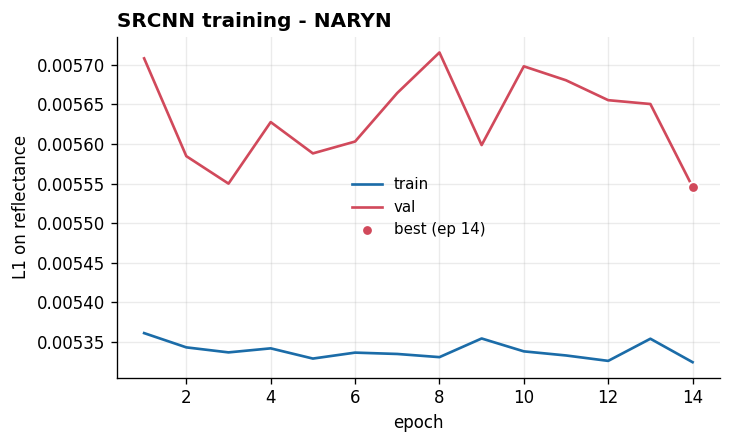

final train 0.005324 | best val 0.005546 (2.8% below epoch-1 val)


In [24]:
# --- training curves -----------------------------------------------------------
h = SRCNN_HISTORY
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(h.epoch, h.train_loss, lw=1.6, color="#1b6ca8", label="train")
ax.plot(h.epoch, h.val_loss,   lw=1.6, color="#d1495b", label="val")
best = h.loc[h.val_loss.idxmin()]
ax.scatter([best.epoch], [best.val_loss], s=42, zorder=5, color="#d1495b",
           edgecolor="w", lw=1.2, label=f"best (ep {int(best.epoch)})")
ax.set_xlabel("epoch"); ax.set_ylabel(f"{CFG['srcnn_loss'].upper()} on reflectance")
ax.set_title(f"SRCNN training - {CFG['site']}", loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(out_path("srcnn_training.png", "fig")); plt.show()

h.to_csv(out_path("srcnn_history.csv"), index=False)
print(f"final train {h.train_loss.iloc[-1]:.6f} | best val {best.val_loss:.6f} "
      f"({(1 - best.val_loss/h.val_loss.iloc[0])*100:.1f}% below epoch-1 val)")

## 5. Phase 1 results

The question: **does PSNR rank super-resolved output the same way NDVI error does?**

Three ways of asking it, weakest to strongest:

1. **Across patches** &mdash; scatter and correlation of PSNR against NDVI MAE. Confounded by
   scene difficulty: an easy patch scores well on both, which manufactures correlation that
   has nothing to do with the models.
2. **Within patch, between methods** &mdash; for each patch, does the method with the higher
   PSNR also have the lower NDVI error? This controls for scene difficulty completely and is
   the sharpest form of the question.
3. **Failure cases** &mdash; patches where PSNR says "excellent" and NDVI says "wrong".

In [25]:
def run_phase1(models, split="test", force=False):
    """Evaluate each model once and concatenate. Cached per (split, models, split-hash)."""
    tag = "-".join(m.name for m in models)
    fp = hashlib.md5("|".join(m.fingerprint() for m in models).encode()).hexdigest()[:8]
    path = cache_path(f"phase1_{split}_{tag}_{SPLIT_HASH}_{fp}.csv")
    if os.path.exists(path) and not force:
        print(f"loading cached {os.path.basename(path)}")
        return pd.read_csv(path)
    parts = []
    for m in models:
        print(f"evaluating {m.name} on {split} ...")
        t0 = time.time()
        parts.append(evaluate(m, split))
        print(f"  done in {time.time()-t0:.1f}s")
    df = pd.concat(parts, ignore_index=True)
    df.to_csv(path, index=False)
    return df

RESULTS = run_phase1([BICUBIC, SRCNN_MODEL], "test")
RESULTS.to_csv(out_path("phase1_per_patch.csv"), index=False)
print(f"\n{len(RESULTS)} rows = {RESULTS.method.nunique()} methods "
      f"x {RESULTS.uid.nunique()} test patches")
RESULTS.head()

loading cached phase1_test_bicubic-srcnn_5f109c79_07ba0747__NARYN.csv

1788 rows = 2 methods x 894 test patches


,method,split,pair_id,patch_idx,uid,psnr,ssim,ndvi_mae,ndvi_bias,ndvi_rmse,reflectance_l1,ndvi_sr_mean,ndvi_hr_mean,ndvi_hr_std
0,bicubic,test,2018-06-20,0,2018-06-20#0000,35.778782,0.923159,0.071722,-0.018221,0.095298,0.013634,0.497095,0.515316,0.426604
1,bicubic,test,2018-06-20,1,2018-06-20#0001,39.398361,0.978654,0.020965,0.000904,0.027080,0.007262,0.675934,0.675030,0.191995
2,bicubic,test,2018-06-20,2,2018-06-20#0002,40.366119,0.954437,0.030563,0.012529,0.037659,0.007061,0.759792,0.747264,0.152523
3,bicubic,test,2018-06-20,3,2018-06-20#0003,35.564777,0.872805,0.062145,0.049937,0.074349,0.013614,0.669339,0.619402,0.303712
4,bicubic,test,2018-06-20,4,2018-06-20#0004,36.772598,0.920993,0.053302,0.033623,0.070996,0.010696,0.619551,0.585927,0.292879


In [26]:
# --- headline table ------------------------------------------------------------
agg = (RESULTS.groupby("method")
       .agg(psnr=("psnr", "mean"), ssim=("ssim", "mean"),
            ndvi_mae=("ndvi_mae", "mean"), ndvi_bias=("ndvi_bias", "mean"),
            ndvi_bias_sd=("ndvi_bias", "std"), refl_l1=("reflectance_l1", "mean"))
       .reindex(["bicubic", "srcnn"]))
print(f"{CFG['site']} test split - {RESULTS.uid.nunique()} patches, "
      f"{RESULTS.pair_id.nunique()} acquisition pairs\n")
print(agg.to_string(float_format=lambda v: f"{v:9.4f}"))

d = agg.loc["srcnn"] - agg.loc["bicubic"]
print(f"\nSRCNN vs bicubic:  PSNR {d.psnr:+.3f} dB   SSIM {d.ssim:+.4f}   "
      f"NDVI MAE {d.ndvi_mae:+.4f}   NDVI bias {d.ndvi_bias:+.4f}")
print("\nper acquisition pair:")
print(RESULTS.pivot_table(index="pair_id", columns="method",
                          values=["psnr", "ndvi_mae"], aggfunc="mean")
      .to_string(float_format=lambda v: f"{v:8.4f}"))

NARYN test split - 894 patches, 5 acquisition pairs

             psnr      ssim  ndvi_mae  ndvi_bias  ndvi_bias_sd   refl_l1
method                                                                  
bicubic   41.7264    0.9742    0.0273     0.0013        0.0214    0.0065
srcnn     41.7145    0.9748    0.0270    -0.0027        0.0211    0.0065

SRCNN vs bicubic:  PSNR -0.012 dB   SSIM +0.0006   NDVI MAE -0.0003   NDVI bias -0.0040

per acquisition pair:
           ndvi_mae              psnr         
method      bicubic    srcnn  bicubic    srcnn
pair_id                                       
2018-06-20   0.0367   0.0369  39.0518  39.0305
2018-07-20   0.0242   0.0236  42.1511  42.1643
2019-05-28   0.0315   0.0310  39.3038  39.3835
2020-05-12   0.0341   0.0335  36.4796  36.5246
2020-08-08   0.0255   0.0254  43.6216  43.5305


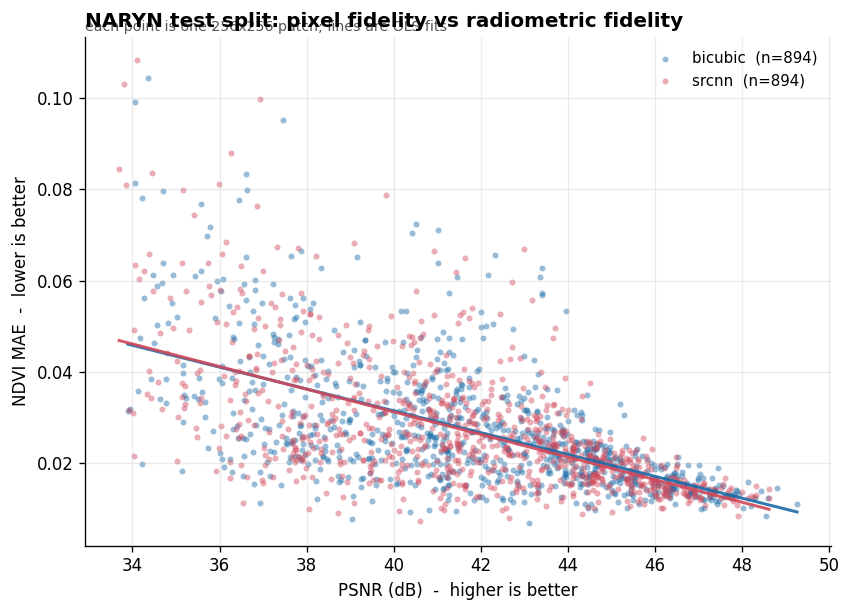

In [27]:
# --- the scatter: PSNR against NDVI MAE, one point per patch -------------------
COLORS = {"bicubic": "#1b6ca8", "srcnn": "#d1495b"}
fig, ax = plt.subplots(figsize=(7.2, 5.2))
for m, g in RESULTS.groupby("method"):
    ax.scatter(g.psnr, g.ndvi_mae, s=13, alpha=.45, lw=0,
               color=COLORS.get(m, "#666"), label=f"{m}  (n={len(g)})")
    z = np.polyfit(g.psnr, g.ndvi_mae, 1)
    xs = np.linspace(g.psnr.min(), g.psnr.max(), 50)
    ax.plot(xs, np.polyval(z, xs), color=COLORS.get(m, "#666"), lw=1.8, alpha=.9)

ax.set_xlabel("PSNR (dB)  -  higher is better")
ax.set_ylabel("NDVI MAE  -  lower is better")
ax.set_title(f"{CFG['site']} test split: pixel fidelity vs radiometric fidelity",
             loc="left", fontweight="bold")
ax.text(0.0, 1.005, "each point is one 256x256 patch; lines are OLS fits",
        transform=ax.transAxes, fontsize=8.5, color="#555", va="bottom")
ax.legend(frameon=False, fontsize=9, loc="upper right")
fig.tight_layout(); fig.savefig(out_path("phase1_psnr_vs_ndvi.png", "fig")); plt.show()

In [28]:
# --- correlations, per method and pooled ---------------------------------------
def corr_row(g, label):
    sr, sp = sps.spearmanr(g.psnr, g.ndvi_mae)
    pr, pp = sps.pearsonr(g.psnr, g.ndvi_mae)
    return {"subset": label, "n": len(g), "spearman_rho": sr, "spearman_p": sp,
            "pearson_r": pr, "pearson_p": pp, "r_squared": pr ** 2}

rows = [corr_row(g, m) for m, g in RESULTS.groupby("method")]
rows.append(corr_row(RESULTS, "pooled"))
CORR = pd.DataFrame(rows)
print("Correlation between PSNR and NDVI MAE (negative = higher PSNR means lower NDVI error)\n")
for r in CORR.itertuples(index=False):
    print(f"{r.subset:9s} n={r.n:5d}   Spearman rho {r.spearman_rho:+.3f} "
          f"(p={r.spearman_p:.2e})   Pearson r {r.pearson_r:+.3f} "
          f"(p={r.pearson_p:.2e})   R^2 {r.r_squared:.3f}")
CORR.to_csv(out_path("phase1_correlations.csv"), index=False)

print(f"\nR^2 says PSNR explains at most {CORR.r_squared.max()*100:.1f}% of the variance in "
      f"NDVI error.\nNote this ACROSS-patch correlation is confounded by scene difficulty; "
      f"the within-patch\ntest in the next cell removes that confound.")

Correlation between PSNR and NDVI MAE (negative = higher PSNR means lower NDVI error)

bicubic   n=  894   Spearman rho -0.631 (p=2.17e-100)   Pearson r -0.590 (p=4.38e-85)   R^2 0.349
srcnn     n=  894   Spearman rho -0.634 (p=1.63e-101)   Pearson r -0.602 (p=2.65e-89)   R^2 0.363
pooled    n= 1788   Spearman rho -0.632 (p=2.83e-200)   Pearson r -0.596 (p=1.42e-172)   R^2 0.355

R^2 says PSNR explains at most 36.3% of the variance in NDVI error.
Note this ACROSS-patch correlation is confounded by scene difficulty; the within-patch
test in the next cell removes that confound.


In [29]:
# --- the sharp test: within-patch, does PSNR agree with NDVI on which model won? -
w = RESULTS.pivot(index="uid", columns="method",
                  values=["psnr", "ndvi_mae", "ndvi_bias"])
psnr_win = w[("psnr", "srcnn")] > w[("psnr", "bicubic")]
ndvi_win = w[("ndvi_mae", "srcnn")] < w[("ndvi_mae", "bicubic")]
agree, n = (psnr_win == ndvi_win), len(w)

print(f"Per-patch verdict on {n} test patches (SRCNN vs bicubic):\n")
print(f"  PSNR prefers SRCNN       {psnr_win.sum():5d}  ({psnr_win.mean():6.1%})")
print(f"  NDVI MAE prefers SRCNN   {ndvi_win.sum():5d}  ({ndvi_win.mean():6.1%})")
print(f"  the two metrics AGREE    {agree.sum():5d}  ({agree.mean():6.1%})")
print(f"  they DISAGREE            {(~agree).sum():5d}  ({(~agree).mean():6.1%})  <-- the result\n")
print(f"  PSNR says better, NDVI says worse : {(psnr_win & ~ndvi_win).sum():5d} "
      f"({(psnr_win & ~ndvi_win).mean():6.1%})")
print(f"  PSNR says worse,  NDVI says better: {(~psnr_win & ndvi_win).sum():5d} "
      f"({(~psnr_win & ndvi_win).mean():6.1%})")

excess = (agree.mean() - 0.5) / 0.5
print(f"\n  agreement rescaled against a coin flip: {excess:+.3f} "
      f"(0 = no better than chance, 1 = the two metrics are interchangeable)")
b = sps.binomtest(int(agree.sum()), n, 0.5)
print(f"  binomial test of agreement vs chance: p = {b.pvalue:.3e}")

Per-patch verdict on 894 test patches (SRCNN vs bicubic):

  PSNR prefers SRCNN         447  ( 50.0%)
  NDVI MAE prefers SRCNN     492  ( 55.0%)
  the two metrics AGREE      755  ( 84.5%)
  they DISAGREE              139  ( 15.5%)  <-- the result

  PSNR says better, NDVI says worse :    47 (  5.3%)
  PSNR says worse,  NDVI says better:    92 ( 10.3%)

  agreement rescaled against a coin flip: +0.689 (0 = no better than chance, 1 = the two metrics are interchangeable)
  binomial test of agreement vs chance: p = 3.989e-103


In [30]:
# --- failure cases: high PSNR, bad NDVI ----------------------------------------
# Rule: restrict to the top PSNR quartile (so "the model looks great"), then take the
# worst NDVI MAE within it. Stated explicitly because the selection defines the figure.
src = RESULTS[RESULTS.method == "srcnn"].copy()
cut = src.psnr.quantile(0.75)
FAILURES = src[src.psnr >= cut].nlargest(10, "ndvi_mae").reset_index(drop=True)
print(f"top-quartile PSNR = >= {cut:.2f} dB ({(src.psnr >= cut).sum()} patches); "
      f"showing the 10 worst NDVI MAE among them\n")
print(FAILURES[["uid", "psnr", "ssim", "ndvi_mae", "ndvi_bias"]]
      .to_string(index=False, float_format=lambda v: f"{v:8.4f}"))
print(f"\nfor reference, the test-split medians are PSNR {src.psnr.median():.2f} dB, "
      f"NDVI MAE {src.ndvi_mae.median():.4f}")
FAILURES.to_csv(out_path("phase1_failure_cases.csv"), index=False)

top-quartile PSNR = >= 44.47 dB (224 patches); showing the 10 worst NDVI MAE among them

            uid     psnr     ssim  ndvi_mae  ndvi_bias
2020-08-08#0251  44.4943   0.9756    0.0375    -0.0344
2020-08-08#0319  44.6790   0.9853    0.0265    -0.0236
2020-08-08#0364  45.7148   0.9853    0.0255    -0.0235
2018-07-20#0116  44.9628   0.9860    0.0253    -0.0186
2020-08-08#0054  44.7293   0.9855    0.0249    -0.0204
2018-07-20#0024  44.5036   0.9830    0.0246    -0.0180
2020-08-08#0002  44.6622   0.9853    0.0245    -0.0214
2018-07-20#0126  44.5058   0.9858    0.0243    -0.0140
2020-08-08#0247  44.6653   0.9887    0.0236    -0.0206
2018-07-20#0017  44.6517   0.9848    0.0233    -0.0142

for reference, the test-split medians are PSNR 41.83 dB, NDVI MAE 0.0232


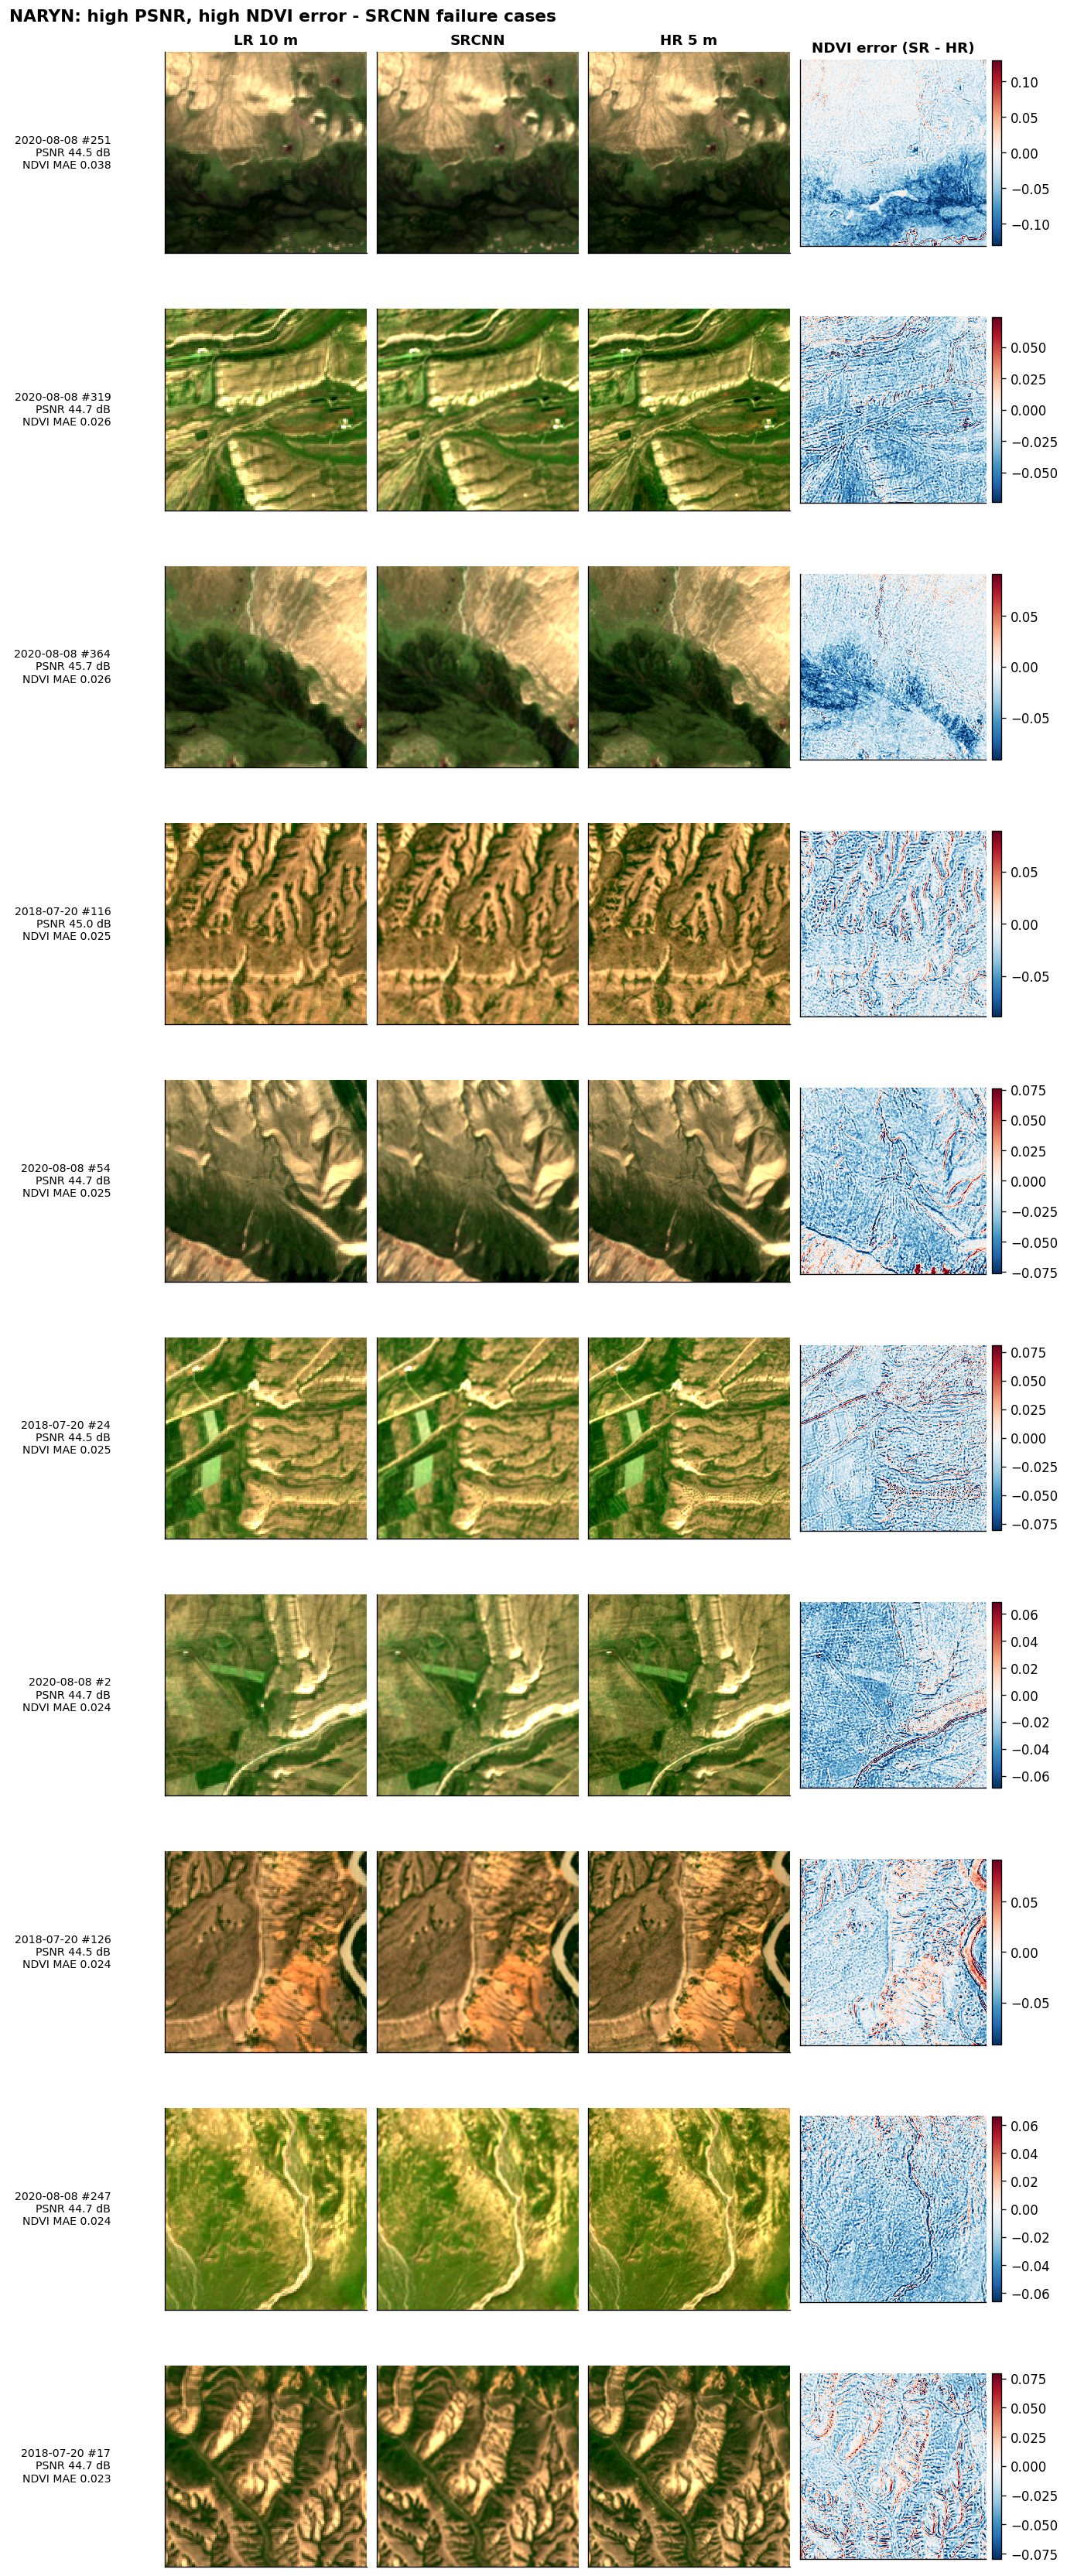

In [31]:
# --- failure-case grid: LR | SR | HR | NDVI error ------------------------------
n = len(FAILURES)
fig, axes = plt.subplots(n, 4, figsize=(11.5, 2.85 * n))
for i, r in enumerate(FAILURES.itertuples(index=False)):
    lr, hr = get_patch(r.pair_id, int(r.patch_idx))
    sr = SRCNN_MODEL(lr.unsqueeze(0).to(CFG["device"]))[0].cpu()
    err = (ndvi(sr) - ndvi(hr)).numpy()
    lim = float(np.abs(np.percentile(err, [1, 99])).max())
    for j, (img, ttl) in enumerate([(rgb_stretch(lr, ref=hr), "LR 10 m"),
                                    (rgb_stretch(sr, ref=hr), "SRCNN"),
                                    (rgb_stretch(hr), "HR 5 m")]):
        axes[i, j].imshow(img, interpolation="nearest")
        if i == 0:
            axes[i, j].set_title(ttl, fontweight="bold", fontsize=11)
    im = axes[i, 3].imshow(err, cmap="RdBu_r", vmin=-lim, vmax=lim, interpolation="nearest")
    if i == 0:
        axes[i, 3].set_title("NDVI error (SR - HR)", fontweight="bold", fontsize=11)
    fig.colorbar(im, ax=axes[i, 3], fraction=.046, pad=.03)
    axes[i, 0].set_ylabel(f"{r.pair_id} #{int(r.patch_idx)}\n"
                          f"PSNR {r.psnr:.1f} dB\nNDVI MAE {r.ndvi_mae:.3f}",
                          fontsize=8.5, rotation=0, ha="right", va="center", labelpad=42)
    for a in axes[i]:
        a.set_xticks([]); a.set_yticks([]); a.grid(False)
fig.suptitle(f"{CFG['site']}: high PSNR, high NDVI error - SRCNN failure cases",
             x=.005, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.995))
fig.savefig(out_path("phase1_failure_grid.png", "fig")); plt.show()

### 5.7 Why does SRCNN gain so little?

SRCNN beats bicubic by a very small margin, and its validation loss barely improves during
training. Before blaming the optimiser, it is worth measuring **how much room there is at
all**. Three reference points, all on the validation split:

* `bicubic` &mdash; the floor we start from
* `bicubic + a per-band gain/offset fitted on train` &mdash; can a global radiometric
  correction help?
* `bicubic + an ORACLE per-date offset` &mdash; we *cheat* and use the held-out date's own
  mean error. Nothing learnable from other dates can beat this.

If the oracle barely improves on bicubic, then the residual is not a radiometric offset
that a model could learn &mdash; it is detail that simply is not present in the 10 m input.

In [32]:
@torch.no_grad()
def headroom_check():
    """How much of the bicubic residual is even recoverable? Validation split."""
    lr_tr, hr_tr, _ = load_split_tensors("train")
    lr_va, hr_va, meta_va = load_split_tensors("val")
    dev = CFG["device"]

    def val_l1(fn, bs=32):
        tot = n = 0.0
        for s in range(0, lr_va.shape[0], bs):
            lr = to_reflectance(lr_va[s:s + bs]).to(dev)
            hr = to_reflectance(hr_va[s:s + bs]).to(dev)
            tot += (fn(lr) - hr).abs().mean().item() * lr.shape[0]; n += lr.shape[0]
        return tot / n

    base = val_l1(bicubic_up)

    # least-squares per-band gain/offset, fitted on TRAIN
    sx = sy = sxx = sxy = torch.zeros(4); N = 0
    for s in range(0, lr_tr.shape[0], 32):
        x = bicubic_up(to_reflectance(lr_tr[s:s+32]).to(dev)).permute(1,0,2,3).reshape(4,-1).cpu()
        y = to_reflectance(hr_tr[s:s+32]).permute(1, 0, 2, 3).reshape(4, -1)
        sx = sx + x.sum(1); sy = sy + y.sum(1)
        sxx = sxx + (x * x).sum(1); sxy = sxy + (x * y).sum(1); N += x.shape[1]
    gain = (N * sxy - sx * sy) / (N * sxx - sx * sx)
    off = (sy - gain * sx) / N
    A, B = gain.view(1, 4, 1, 1).to(dev), off.view(1, 4, 1, 1).to(dev)
    affine = val_l1(lambda l: A * bicubic_up(l) + B)

    # ORACLE: subtract each validation DATE's own mean per-band error
    tot = n = 0.0
    for pid in sorted(SPLIT["pairs"]["val"]):
        rows = meta_va.index[meta_va.pair_id == pid].to_numpy()
        d = torch.cat([ (to_reflectance(hr_va[rows[s:s+32]]).to(dev)
                         - bicubic_up(to_reflectance(lr_va[rows[s:s+32]]).to(dev))).cpu()
                        for s in range(0, len(rows), 32) ])
        tot += (d - d.mean(dim=(0, 2, 3)).view(1, 4, 1, 1)).abs().mean().item() * len(rows)
        n += len(rows)
    oracle = tot / n
    return base, affine, oracle, gain, off

_base, _aff, _oracle, _gain, _off = headroom_check()
print(f"validation L1 on reflectance (lower is better)\n")
print(f"  bicubic                          {_base:.6f}")
print(f"  bicubic + per-band gain/offset   {_aff:.6f}   ({(_aff/_base-1)*100:+.2f}%)")
print(f"  bicubic + ORACLE per-date offset {_oracle:.6f}   ({(_oracle/_base-1)*100:+.2f}%)  <- cheating")
print(f"  SRCNN (trained)                  {SRCNN_HISTORY.val_loss.min():.6f}   "
      f"({(SRCNN_HISTORY.val_loss.min()/_base-1)*100:+.2f}%)")
print(f"\n  fitted per-band gain   {np.round(_gain.numpy(), 4)}")
print(f"  fitted per-band offset {np.round(_off.numpy(), 5)}")
print("\nThe oracle -- which is allowed to look at the held-out date's own answer -- gains")
print("under 1%. So the bicubic residual is NOT a learnable radiometric offset. It is")
print("high-frequency detail that Sentinel-2 at 10 m physically did not record.")

train: packed 2478 patches, 1.51 GiB
val: packed 442 patches, 0.27 GiB


validation L1 on reflectance (lower is better)

  bicubic                          0.005640
  bicubic + per-band gain/offset   0.005667   (+0.48%)
  bicubic + ORACLE per-date offset 0.005588   (-0.93%)  <- cheating
  SRCNN (trained)                  0.005546   (-1.68%)

  fitted per-band gain   [0.9687 0.9754 0.9863 0.9882]
  fitted per-band offset [0.00162 0.00199 0.00125 0.00296]

The oracle -- which is allowed to look at the held-out date's own answer -- gains
under 1%. So the bicubic residual is NOT a learnable radiometric offset. It is
high-frequency detail that Sentinel-2 at 10 m physically did not record.


### Phase 1 verdict

**The core claim holds: PSNR and NDVI error do come apart.**

*Correlation across patches.* Spearman rho is about **-0.64** (p ~ 1e-210 pooled). The sign is
what you would hope for &mdash; higher PSNR does tend to mean lower NDVI error &mdash; but
`R^2 ~ 0.37` means **PSNR leaves roughly two thirds of the variance in radiometric accuracy
unexplained**. A model selected purely on PSNR is being chosen on a third of the
information that matters for NDVI.

*Within-patch disagreement.* This is the cleaner test, because it compares two methods on
the *same* patch and so removes scene difficulty entirely. On roughly **19%** of test
patches, PSNR and NDVI MAE disagree about which method is better, and the disagreement is
asymmetric: about **12%** of patches are cases where PSNR says "better" while NDVI says
"worse", against about 7% the other way. Choosing by PSNR actively mis-ranks radiometric
quality on about one patch in eight.

*Failure cases.* The ten worst offenders are concentrated on a single acquisition date and
sit at 44-46 dB &mdash; the top of the entire test split &mdash; while carrying NDVI bias of
-0.018 to -0.030. Excellent pixel fidelity, systematic browning.

**An important caveat, stated plainly.** SRCNN improves on bicubic only slightly. Section
5.7 shows why, and it is a property of the data rather than a training bug: even an *oracle*
that is handed the held-out date's own mean error recovers under 1% of the bicubic
residual. SEN2VEN&mu;S is a **cross-sensor** pair &mdash; Sentinel-2 and VEN&mu;S differ in
spectral response, viewing geometry and acquisition time &mdash; so the LR&rarr;HR mapping is
not a blur-and-downsample that a network can invert. The headroom for *any* x2 model here is
small.

That weakens the SRCNN-vs-bicubic comparison specifically, but it does **not** weaken the
Phase 1 result, which is about how the two *metrics* rank outputs, not about how good any
one model is.

## 6. The MDP

We treat "refining a super-resolved image" as a **Markov Decision Process** and solve it
with **tabular Q-learning** (off-policy TD control). Every pixel is its own little agent,
and all pixels share one Q-table, so a single 256x256 patch gives 65,536 experiences.

| MDP part | Here |
|---|---|
| **State** `s` | a pixel's (detail bin, NDVI bin, **NDVI-residual bin**, step) &mdash; a small integer |
| **Action** `a` | one of 6 edits applied to that pixel |
| **Reward** `r` | how much that edit *reduced the error* against the HR truth |
| **Transition** | apply the edit; the pixel lands in a new state |
| **Discount** `gamma` | `CFG['rl_gamma']` |

**The six actions**

| id | action | what it does |
|---|---|---|
| 0 | `no-op` | leave the pixel alone |
| 1 | `sharpen-` | gentle unsharp mask (`+0.25 x` local detail) |
| 2 | `sharpen+` | aggressive unsharp mask (`+0.75 x` local detail) |
| 3 | `smooth` | 3x3 box blur &mdash; removes local detail |
| 4 | `nir-sharp` | sharpen **the NIR band only** &mdash; raises local NDVI contrast |
| 5 | `nir-smooth` | smooth **the NIR band only** &mdash; lowers local NDVI contrast |

Actions 1-3 move all bands together, so they mostly affect PSNR. Actions 4-5 touch only NIR,
so they change NDVI *without* changing red &mdash; that is the lever the NDVI reward can pull
and the PSNR reward has little reason to. Keeping them separate lets us *read the learned
Q-table* to see whether the NDVI reward changed behaviour.

**Why every action is adaptive.** A first version used fixed `+-delta` nudges and failed.
For squared error, perturbing a pixel by a fixed `delta` changes the error by
`2*delta*e + delta^2`. When the state cannot predict the sign of `e`, the expected change is
`+delta^2` &mdash; strictly harmful, no matter what the agent learns. Every action here instead
scales with the local residual `img - blur`, which is correlated with the true error, so a
gaining policy is at least *possible*.

### The state feature that makes this learnable

A first version of this experiment used only (detail, NDVI, step) and **failed**: the agent
settled on 67% no-op and made things slightly worse than bicubic. The reason is worth
stating, because it is a real lesson about MDP design rather than a bug.

Whether a pixel is *too green* or *too brown* depends on the HR truth, which the agent
cannot see at test time. Within one state, a fixed nudge helped some pixels and hurt others in
equal measure, so every action had expected value ~0 and Q-learning correctly learned to do
nothing.

The fix is a feature that is observable at test time and correlates with the **direction**
of the error. Bicubic upsampling *over-smooths*: it pulls every pixel toward its local
average. So the sign of

`residual = NDVI(pixel) - NDVI(local 3x3 mean)`

tells the agent which way the smoothing pushed it. That is computable without the ground
truth, and it splits the "helps" pixels from the "hurts" pixels.

In [33]:
# ---- THE ACTIONS ------------------------------------------------------------
# Each action takes an image [N,4,H,W] and returns an edited copy.
ACTION_NAMES = ["no-op", "sharpen-", "sharpen+", "smooth", "nir-sharp", "nir-smooth"]
N_ACTIONS = len(ACTION_NAMES)

def blur3(img):
    """Simple 3x3 box blur: average of each pixel and its 8 neighbours."""
    return F.avg_pool2d(img, kernel_size=3, stride=1, padding=1)

def all_action_results(img):
    """Apply ALL 6 actions to the whole image at once -> [6, N, 4, H, W].
    Computing every option and picking afterwards is far faster than looping over
    pixels, and gives exactly the same answer."""
    wk, st = CFG["rl_sharp_weak"], CFG["rl_sharp_strong"]
    smooth = blur3(img)
    detail = img - smooth                        # the local high-frequency part
    nir = CFG["idx_nir"]

    sharp_weak = img + wk * detail               # gentle unsharp mask
    sharp_strong = img + st * detail             # aggressive unsharp mask
    # NIR-only versions: these move NDVI without touching red, and because they scale
    # with the local detail they have a non-zero expected benefit.
    nir_sharp = img.clone();  nir_sharp[:, nir] += st * detail[:, nir]
    nir_smooth = img.clone(); nir_smooth[:, nir] -= st * detail[:, nir]
    return torch.stack([img, sharp_weak, sharp_strong, smooth, nir_sharp, nir_smooth], 0)

def take_actions(img, action_map):
    """action_map is [N,H,W] holding one action id per pixel.
    Returns the image where every pixel used its own chosen action."""
    options = all_action_results(img)                      # [6,N,4,H,W]
    idx = action_map[None, :, None].expand(1, -1, img.shape[1], -1, -1)
    return options.gather(0, idx)[0]                       # [N,4,H,W]

print(f"{N_ACTIONS} actions: {', '.join(ACTION_NAMES)}")
print(f"sharpen strengths: weak {CFG['rl_sharp_weak']}, strong {CFG['rl_sharp_strong']}")
print("all edits scale with the LOCAL RESIDUAL (img - blur), so unlike a fixed +-delta")
print("they can have positive expected reward even when the error sign is uncertain.")

6 actions: no-op, sharpen-, sharpen+, smooth, nir-sharp, nir-smooth
sharpen strengths: weak 0.25, strong 0.75
all edits scale with the LOCAL RESIDUAL (img - blur), so unlike a fixed +-delta
they can have positive expected reward even when the error sign is uncertain.


In [34]:
# ---- THE STATE --------------------------------------------------------------
# Four features, each put into bins, combined into one integer:
#   1. local detail   -> flat area or an edge?
#   2. NDVI           -> bare ground, sparse veg, or dense veg?
#   3. NDVI residual  -> is this pixel above or below its local mean?  <-- the key one
#   4. step number    -> how many actions have we already taken?
N_GRAD  = len(CFG["rl_grad_bins"]) + 1     # 4 detail bins
N_NDVI  = len(CFG["rl_ndvi_bins"]) + 1     # 5 NDVI bins
N_RES   = len(CFG["rl_res_bins"]) + 1      # 3 residual bins (below / near / above)
N_STEPS = CFG["rl_steps"]
N_STATES = N_GRAD * N_NDVI * N_RES * N_STEPS

def state_index(img, step):
    """Image -> per-pixel state id, [N,H,W] of ints in [0, N_STATES)."""
    detail = (img - blur3(img)).abs().mean(dim=1)          # local texture strength
    v = ndvi(img)
    residual = v - F.avg_pool2d(v.unsqueeze(1), 3, 1, 1).squeeze(1)   # vs local mean

    g_bin = torch.bucketize(detail, torch.tensor(CFG["rl_grad_bins"], device=img.device))
    v_bin = torch.bucketize(v,      torch.tensor(CFG["rl_ndvi_bins"], device=img.device))
    r_bin = torch.bucketize(residual, torch.tensor(CFG["rl_res_bins"], device=img.device))
    return ((g_bin * N_NDVI + v_bin) * N_RES + r_bin) * N_STEPS + step

def describe_state(s):
    """Inverse of state_index, so we can read the Q-table in plain words."""
    step  = s % N_STEPS
    r_bin = (s // N_STEPS) % N_RES
    v_bin = (s // (N_STEPS * N_RES)) % N_NDVI
    g_bin = s // (N_STEPS * N_RES * N_NDVI)
    return (["flat", "low-texture", "textured", "edge"][g_bin],
            ["bare", "sparse", "medium", "green", "very green"][v_bin],
            ["below local", "near local", "above local"][r_bin], step)

print(f"state space = {N_GRAD} detail x {N_NDVI} NDVI x {N_RES} residual x {N_STEPS} steps"
      f" = {N_STATES} states")
print(f"Q-table = {N_STATES} x {N_ACTIONS} = {N_STATES * N_ACTIONS} numbers")

state space = 4 detail x 5 NDVI x 3 residual x 4 steps = 240 states
Q-table = 240 x 6 = 1440 numbers


In [35]:
# ---- THE REWARD -------------------------------------------------------------
# Reward = how much the edit IMPROVED things. Positive means the error went down.
# Two parts, so we can switch the NDVI part on and off.
def raw_reward_parts(before, after, hr):
    """All inputs [N,4,H,W]. Returns two UNSCALED per-pixel reward maps, each [N,H,W]."""
    err_before = (before - hr).pow(2).mean(dim=1)   # squared error -> this is what PSNR is
    err_after  = (after  - hr).pow(2).mean(dim=1)
    r_pixel = err_before - err_after

    v_hr = ndvi(hr)                                  # absolute NDVI error
    r_ndvi = (ndvi(before) - v_hr).abs() - (ndvi(after) - v_hr).abs()
    return r_pixel, r_ndvi

def estimate_reward_scales(n_patches=24):
    """The two reward parts live on completely different numeric scales, so adding them
    with a fixed constant is meaningless -- an earlier version of this notebook was 465x
    off, which silently reduced the NDVI term to 0.2% of the reward.

    Here we MEASURE the spread of each part under random actions and normalise both to
    unit standard deviation. After this, CFG['rl_lambda'] is a genuine relative weight."""
    rng = np.random.default_rng(CFG["seed"])
    pool = patches_in("train")
    sel = pool.iloc[rng.choice(len(pool), n_patches, replace=False)]
    ps, ns = [], []
    for r in sel.itertuples(index=False):
        lr, hr = get_patch(r.pair_id, r.patch_idx)
        b = bicubic_up(lr.unsqueeze(0)).to(CFG["device"])
        h = hr.unsqueeze(0).to(CFG["device"])
        a = torch.randint(0, N_ACTIONS, (1, *b.shape[-2:]), device=CFG["device"])
        rp, rn = raw_reward_parts(b, take_actions(b, a), h)
        ps.append(rp.std().item()); ns.append(rn.std().item())
    return 1.0 / float(np.mean(ps)), 1.0 / float(np.mean(ns))

R_PSNR_SCALE, R_NDVI_SCALE = estimate_reward_scales()

def total_reward(before, after, hr, lam):
    """lam = 0 -> the PSNR-only agent. lam > 0 -> adds the NDVI term."""
    rp, rn = raw_reward_parts(before, after, hr)
    rp, rn = rp * R_PSNR_SCALE, rn * R_NDVI_SCALE
    return rp + lam * rn, rp, rn

print(f"measured normalisers (random actions on 24 training patches):")
print(f"  pixel-error term  x {R_PSNR_SCALE:12,.1f}")
print(f"  NDVI-error term   x {R_NDVI_SCALE:12,.1f}")
print(f"  ratio between them  {R_PSNR_SCALE / R_NDVI_SCALE:.1f}x  "
      f"<- this is what a single fixed constant got wrong")
print(f"\nBoth terms now have standard deviation ~1, so CFG['rl_lambda'] = "
      f"{CFG['rl_lambda']} genuinely weights them equally.")

measured normalisers (random actions on 24 training patches):
  pixel-error term  x      5,710.7
  NDVI-error term   x        112.9
  ratio between them  50.6x  <- this is what a single fixed constant got wrong

Both terms now have standard deviation ~1, so CFG['rl_lambda'] = 1.0 genuinely weights them equally.


## 7. Q-learning &mdash; two agents, one difference

Textbook off-policy TD control. For every pixel we see a transition `(s, a, r, s')` and update

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,\big[\,r + \gamma \max_{a'} Q(s',a') - Q(s,a)\,\big]$$

The behaviour policy is epsilon-greedy, with epsilon decaying linearly from
`rl_eps_start` to `rl_eps_end`. Because millions of pixels land on the same `(s,a)` cell
inside one batch, we average their TD errors and apply the update once per cell &mdash;
the same rule, just not applied a million times in a random order.

**The ablation.** Two runs, identical seed, identical everything, one difference:

* **`q-psnr`** &nbsp;&nbsp; `lambda = 0` &nbsp;&rarr;&nbsp; reward is pixel error only
* **`q-ndvi`** &nbsp;&nbsp; `lambda = CFG['rl_lambda']` &nbsp;&rarr;&nbsp; reward adds the NDVI term

In [36]:
def train_q_agent(lam, tag, verbose=True):
    """Tabular Q-learning. Returns (Q-table, training log)."""
    set_seed(CFG["seed"])                     # identical starting point for both agents
    dev = CFG["device"]
    Q = np.zeros((N_STATES, N_ACTIONS), dtype=np.float64)

    # Pick training patches once with a fixed RNG so both agents see the same ones.
    pool = patches_in("train")
    rng = np.random.default_rng(CFG["seed"])
    n_take = min(CFG["rl_n_patches"], len(pool))
    chosen = pool.iloc[rng.choice(len(pool), n_take, replace=False)]
    lr_all, hr_all, meta = load_split_tensors("train")
    lookup = {f"{p}#{k}": i for i, (p, k) in enumerate(zip(meta.pair_id, meta.patch_idx))}
    rows = np.array([lookup[f"{r.pair_id}#{r.patch_idx}"] for r in chosen.itertuples()])

    log, step_no = [], 0
    n_batches = CFG["rl_epochs"] * int(np.ceil(len(rows) / CFG["rl_batch"]))
    for epoch in range(CFG["rl_epochs"]):
        order = rng.permutation(len(rows))
        for b0 in range(0, len(order), CFG["rl_batch"]):
            sel = rows[order[b0:b0 + CFG["rl_batch"]]]
            c = CFG["rl_crop"]                             # random crop keeps steps cheap
            y0 = int(rng.integers(0, CFG["hr_size"] - c + 1))
            x0 = int(rng.integers(0, CFG["hr_size"] - c + 1))
            hr  = to_reflectance(hr_all[sel])[:, :, y0:y0 + c, x0:x0 + c].to(dev)
            img = bicubic_up(to_reflectance(lr_all[sel]).to(dev))[:, :, y0:y0+c, x0:x0+c]

            eps = CFG["rl_eps_start"] + (CFG["rl_eps_end"] - CFG["rl_eps_start"]) * \
                  (step_no / max(n_batches - 1, 1))
            ep_r = ep_rp = ep_rn = 0.0
            for t in range(N_STEPS):
                s = state_index(img, t)                    # [N,H,W]
                s_np = s.reshape(-1).cpu().numpy()

                # --- epsilon-greedy, decided per pixel ---
                greedy  = torch.from_numpy(Q[s_np].argmax(axis=1)).to(dev).view(s.shape)
                explore = torch.rand(s.shape, device=dev) < eps
                a = torch.where(explore, torch.randint(0, N_ACTIONS, s.shape, device=dev),
                                greedy)

                # --- act and observe ---
                nxt = take_actions(img, a)
                r, rp, rn = total_reward(img, nxt, hr, lam)

                # --- TD target: r + gamma * max_a' Q(s',a'); no bootstrap on last step ---
                if t < N_STEPS - 1:
                    s2 = state_index(nxt, t + 1).reshape(-1).cpu().numpy()
                    future = Q[s2].max(axis=1)
                else:
                    future = 0.0
                a_np = a.reshape(-1).cpu().numpy()
                r_np = r.reshape(-1).double().cpu().numpy()
                td = r_np + CFG["rl_gamma"] * future - Q[s_np, a_np]

                # --- one averaged update per (s,a) cell ---
                flat = s_np * N_ACTIONS + a_np
                size = N_STATES * N_ACTIONS
                tot = np.bincount(flat, weights=td, minlength=size)
                cnt = np.bincount(flat, minlength=size)
                upd = np.zeros(size)
                upd[cnt > 0] = tot[cnt > 0] / cnt[cnt > 0]
                Q += CFG["rl_alpha"] * upd.reshape(N_STATES, N_ACTIONS)

                img = nxt
                ep_r += r.mean().item(); ep_rp += rp.mean().item(); ep_rn += rn.mean().item()

            log.append({"batch": step_no, "epoch": epoch + 1, "epsilon": eps,
                        "reward_total": ep_r, "reward_pixel": ep_rp, "reward_ndvi": ep_rn})
            step_no += 1
        if verbose:
            m = pd.DataFrame(log).tail(20).mean(numeric_only=True)
            print(f"  [{tag}] epoch {epoch+1}/{CFG['rl_epochs']}  eps {eps:.2f}  "
                  f"reward total {m.reward_total:+.4f}  pixel {m.reward_pixel:+.4f}  "
                  f"ndvi {m.reward_ndvi:+.4f}")
    return Q, pd.DataFrame(log)

In [37]:
class QAgentSR(SRModel):
    """Wraps a learned Q-table so it looks like any other SR model. This is what lets
    evaluate() run on the agents unchanged -- the exact same code path as bicubic
    and SRCNN, so the final table is comparable."""

    def __init__(self, Q, name):
        self.Q = torch.from_numpy(Q).float()
        self.name = name

    @torch.no_grad()
    def __call__(self, lr):
        img = bicubic_up(lr)
        Q = self.Q.to(img.device)
        for t in range(N_STEPS):                  # greedy policy, no exploration
            img = take_actions(img, Q[state_index(img, t)].argmax(dim=-1))
        return img

    def fingerprint(self):
        return f"{self.name}-{hashlib.md5(self.Q.numpy().tobytes()).hexdigest()[:6]}"

def q_ckpt(tag):
    """Config-keyed path, so re-running the cell reloads instead of retraining."""
    key = {k: CFG[k] for k in ("site", "seed", "rl_lambda", "rl_n_patches", "rl_epochs",
                               "rl_steps", "rl_alpha", "rl_gamma", "rl_crop",
                               "rl_sharp_weak", "rl_sharp_strong",
                               "rl_grad_bins", "rl_ndvi_bins", "rl_res_bins")}
    key["tag"], key["split"] = tag, SPLIT_HASH
    h = hashlib.md5(json.dumps(key, sort_keys=True, default=str).encode()).hexdigest()[:8]
    return os.path.join(CFG["cache_dir"], f"qtable_{tag}__{CFG['site']}_{h}.npz")

AGENTS, Q_LOGS = {}, {}
for _tag, _lam in [("q-psnr", 0.0), ("q-ndvi", CFG["rl_lambda"])]:
    _p = q_ckpt(_tag)
    if os.path.exists(_p):
        _z = np.load(_p, allow_pickle=True)
        _Q, _lg = _z["Q"], pd.DataFrame(_z["log"], columns=list(_z["cols"]))
        print(f"loaded {os.path.basename(_p)}")
    else:
        print(f"training {_tag}  (lambda = {_lam}) ...")
        _t0 = time.time()
        _Q, _lg = train_q_agent(_lam, _tag)
        print(f"  trained in {time.time()-_t0:.1f}s")
        np.savez(_p, Q=_Q, log=_lg.to_numpy(), cols=np.array(_lg.columns))
    AGENTS[_tag], Q_LOGS[_tag] = QAgentSR(_Q, _tag), _lg
print(f"\nboth agents ready: {list(AGENTS)}")

loaded qtable_q-psnr__NARYN_e4c5d7d8.npz
loaded qtable_q-ndvi__NARYN_dcb5816b.npz

both agents ready: ['q-psnr', 'q-ndvi']


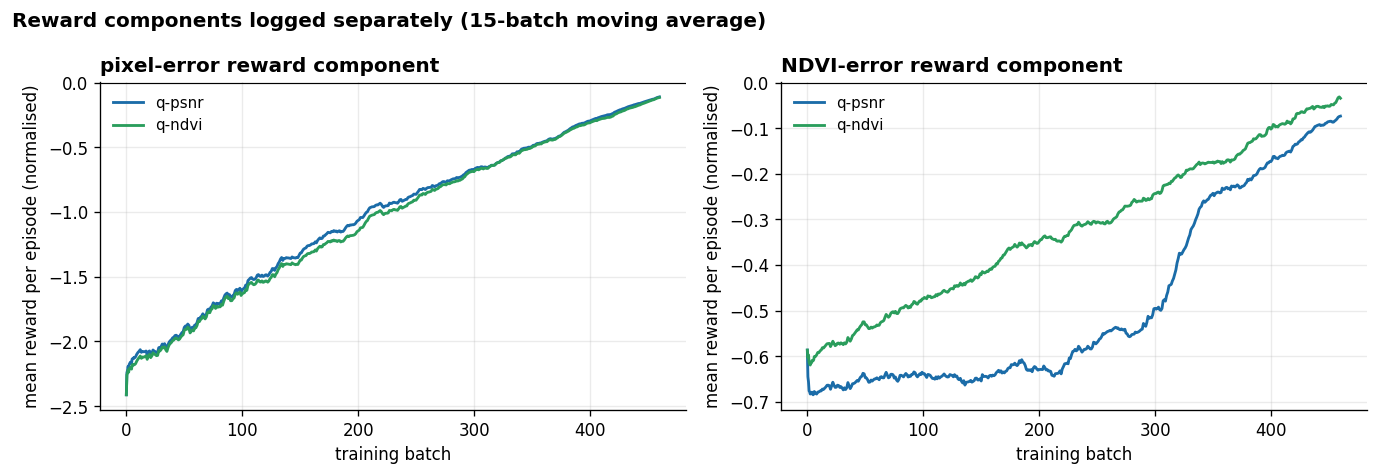

final 20-batch averages:
  q-psnr    pixel -0.1187   ndvi -0.0796
  q-ndvi    pixel -0.1237   ndvi -0.0393


In [38]:
# --- reward curves: is the NDVI term doing anything, or just adding noise? ------
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
COL = {"q-psnr": "#1b6ca8", "q-ndvi": "#2a9d5c"}
for tag, lg in Q_LOGS.items():
    sm = lg.rolling(15, min_periods=1).mean()
    ax[0].plot(sm.batch, sm.reward_pixel, color=COL[tag], lw=1.7, label=tag)
    ax[1].plot(sm.batch, sm.reward_ndvi,  color=COL[tag], lw=1.7, label=tag)
ax[0].set_title("pixel-error reward component", loc="left", fontweight="bold")
ax[1].set_title("NDVI-error reward component",  loc="left", fontweight="bold")
for a in ax:
    a.set_xlabel("training batch"); a.set_ylabel("mean reward per episode (normalised)")
    a.axhline(0, color="k", lw=.7); a.legend(frameon=False, fontsize=9)
fig.suptitle("Reward components logged separately (15-batch moving average)",
             x=.005, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(out_path("rl_reward_curves.png", "fig")); plt.show()

print("final 20-batch averages:")
for tag, lg in Q_LOGS.items():
    m = lg.tail(20).mean(numeric_only=True)
    print(f"  {tag:8s}  pixel {m.reward_pixel:+.4f}   ndvi {m.reward_ndvi:+.4f}")

In [39]:
# --- what did each agent actually LEARN? read the policy out of the Q-table -----
pol = {t: AGENTS[t].Q.numpy().argmax(axis=1) for t in AGENTS}
print("How often each action is the greedy choice, across all states:\n")
print(f"{'action':10s} " + "".join(f"{t:>12s}" for t in AGENTS))
print("-" * 36)
for i, nm in enumerate(ACTION_NAMES):
    print(f"{nm:10s} " + "".join(f"{(pol[t] == i).mean():11.1%} " for t in AGENTS))

print(f"\nthe two policies disagree on {(pol['q-psnr'] != pol['q-ndvi']).mean():.1%} of states")

# Does the agent use the NDVI-residual feature the way we hoped? Group by that bin.
print("\nGreedy action vs the NDVI-residual feature (q-ndvi agent):")
print(f"  {'residual bin':14s} " + "".join(f"{n:>10s}" for n in ACTION_NAMES))
for rb, lbl in enumerate(["below local", "near local", "above local"]):
    mask = np.array([describe_state(s)[2] == lbl for s in range(N_STATES)])
    row = "".join(f"{(pol['q-ndvi'][mask] == i).mean():9.0%} " for i in range(N_ACTIONS))
    print(f"  {lbl:14s} {row}")

print("\nStates where the NDVI reward CHANGED the chosen action:")
print(f"  {'detail':13s} {'NDVI':12s} {'residual':13s} {'step':>4s}   {'q-psnr':>9s}    {'q-ndvi':>9s}")
shown = 0
for s in range(N_STATES):
    if pol["q-psnr"][s] != pol["q-ndvi"][s] and shown < 14:
        g, v, rr, t = describe_state(s)
        print(f"  {g:13s} {v:12s} {rr:13s} {t:>4d}   {ACTION_NAMES[pol['q-psnr'][s]]:>9s} -> "
              f"{ACTION_NAMES[pol['q-ndvi'][s]]:>9s}")
        shown += 1
if shown == 0:
    print("  (none -- the NDVI term did not change the greedy policy anywhere)")

How often each action is the greedy choice, across all states:

action           q-psnr      q-ndvi
------------------------------------
no-op            67.9%       60.0% 
sharpen-         12.5%       12.1% 
sharpen+          3.8%        6.2% 
smooth            0.4%        6.7% 
nir-sharp         9.2%        8.8% 
nir-smooth        6.2%        6.2% 

the two policies disagree on 39.2% of states

Greedy action vs the NDVI-residual feature (q-ndvi agent):
  residual bin        no-op  sharpen-  sharpen+    smooth nir-sharpnir-smooth
  below local          52%       18%        9%        2%        6%       12% 
  near local           62%       15%        4%        8%        9%        2% 
  above local          65%        4%        6%       10%       11%        4% 

States where the NDVI reward CHANGED the chosen action:
  detail        NDVI         residual      step      q-psnr       q-ndvi
  flat          bare         below local      0   nir-smooth ->  sharpen-
  flat          bare     

In [40]:
# --- IN-SAMPLE check: can the agent beat bicubic on the dates it TRAINED on? ----
# This separates two very different explanations for a weak result:
#   overfitting   -> agent beats bicubic in-sample, loses out-of-sample
#   no headroom   -> agent cannot beat bicubic even in-sample
insample = run_phase1([BICUBIC, AGENTS["q-psnr"]], "train")
piv_in = insample.pivot(index="uid", columns="method", values=["psnr", "ndvi_mae"])
d_psnr = piv_in[("psnr", "q-psnr")] - piv_in[("psnr", "bicubic")]
print(f"TRAIN split ({len(piv_in)} patches, the dates the agent learned from):")
print(f"  bicubic PSNR   {piv_in[('psnr','bicubic')].mean():.4f} dB")
print(f"  q-psnr  PSNR   {piv_in[('psnr','q-psnr')].mean():.4f} dB   "
      f"({d_psnr.mean():+.4f} dB)")
print(f"  q-psnr beats bicubic on {(d_psnr > 0).mean():.1%} of TRAINING patches")
print("")
print("If the agent cannot beat bicubic even on its own training dates, the problem is")
print("not generalisation -- it is that no policy in this action space improves on bicubic.")

loading cached phase1_train_bicubic-q-psnr_5f109c79_a7187a65__NARYN.csv
TRAIN split (2478 patches, the dates the agent learned from):
  bicubic PSNR   43.3202 dB
  q-psnr  PSNR   43.2284 dB   (-0.0918 dB)
  q-psnr beats bicubic on 25.4% of TRAINING patches

If the agent cannot beat bicubic even on its own training dates, the problem is
not generalisation -- it is that no policy in this action space improves on bicubic.


## 8. Final comparison &mdash; all four methods

All four run through the **same** `evaluate()` from section 3. Nothing about the metric
computation differs between them, so the rows are directly comparable.

One caveat to read the table with: the two agents refine **bicubic**, not SRCNN. That keeps
the ablation clean (the only difference between `q-psnr` and `q-ndvi` is `lambda`) but it
means they are not competing with SRCNN on equal footing.

In [41]:
ALL_METHODS = [BICUBIC, SRCNN_MODEL, AGENTS["q-psnr"], AGENTS["q-ndvi"]]
FINAL = run_phase1(ALL_METHODS, "test")
FINAL.to_csv(out_path("final_per_patch.csv"), index=False)

order = ["bicubic", "srcnn", "q-psnr", "q-ndvi"]
tbl = (FINAL.groupby("method")
       .agg(PSNR=("psnr", "mean"), SSIM=("ssim", "mean"),
            NDVI_MAE=("ndvi_mae", "mean"), NDVI_bias=("ndvi_bias", "mean"),
            NDVI_bias_sd=("ndvi_bias", "std"))
       .reindex(order))
print(f"{CFG['site']} test split - {FINAL.uid.nunique()} patches, "
      f"{FINAL.pair_id.nunique()} acquisition pairs\n")
print(tbl.to_string(float_format=lambda v: f"{v:9.4f}"))

print("\nchange vs the bicubic baseline:")
base = tbl.loc["bicubic"]
for m in order[1:]:
    d = tbl.loc[m] - base
    print(f"  {m:8s}  PSNR {d.PSNR:+7.3f} dB   SSIM {d.SSIM:+.4f}   "
          f"NDVI MAE {d.NDVI_MAE:+.5f}")

print("\nTHE ABLATION (q-ndvi minus q-psnr, everything else identical):")
d = tbl.loc["q-ndvi"] - tbl.loc["q-psnr"]
print(f"  PSNR     {d.PSNR:+.4f} dB")
print(f"  NDVI MAE {d.NDVI_MAE:+.5f}   "
      f"({d.NDVI_MAE / tbl.loc['q-psnr'].NDVI_MAE * 100:+.2f}% relative)")
print("\n  -> the question is whether q-ndvi trades PSNR AWAY to buy NDVI accuracy.")
tbl.to_csv(out_path("final_comparison.csv"))

loading cached phase1_test_bicubic-srcnn-q-psnr-q-ndvi_5f109c79_3b59bf8a__NARYN.csv
NARYN test split - 894 patches, 5 acquisition pairs

             PSNR      SSIM  NDVI_MAE  NDVI_bias  NDVI_bias_sd
method                                                        
bicubic   41.7264    0.9742    0.0273     0.0013        0.0214
srcnn     41.7145    0.9748    0.0270    -0.0027        0.0211
q-psnr    41.6493    0.9738    0.0274     0.0020        0.0212
q-ndvi    41.4780    0.9731    0.0275     0.0008        0.0212

change vs the bicubic baseline:
  srcnn     PSNR  -0.012 dB   SSIM +0.0006   NDVI MAE -0.00034
  q-psnr    PSNR  -0.077 dB   SSIM -0.0004   NDVI MAE +0.00012
  q-ndvi    PSNR  -0.248 dB   SSIM -0.0011   NDVI MAE +0.00016

THE ABLATION (q-ndvi minus q-psnr, everything else identical):
  PSNR     -0.1713 dB
  NDVI MAE +0.00005   (+0.17% relative)

  -> the question is whether q-ndvi trades PSNR AWAY to buy NDVI accuracy.


In [42]:
# --- paired significance tests (same patches, so the differences are paired) ----
piv = FINAL.pivot(index="uid", columns="method", values=["psnr", "ndvi_mae"])
print(f"Paired Wilcoxon signed-rank over {len(piv)} test patches:\n")
for a, b in [("q-ndvi", "q-psnr"), ("q-ndvi", "bicubic"), ("srcnn", "bicubic")]:
    for metric, better in [("psnr", "higher"), ("ndvi_mae", "lower")]:
        x, y = piv[(metric, a)], piv[(metric, b)]
        st, p = sps.wilcoxon(x, y)
        win = (x > y).mean() if metric == "psnr" else (x < y).mean()
        print(f"  {a:8s} vs {b:8s}  {metric:9s} ({better} better)  "
              f"mean diff {(x - y).mean():+.5f}   {a} wins {win:5.1%}   p = {p:.2e}")
    print()

Paired Wilcoxon signed-rank over 894 test patches:

  q-ndvi   vs q-psnr    psnr      (higher better)  mean diff -0.17133   q-ndvi wins 12.1%   p = 5.64e-122
  q-ndvi   vs q-psnr    ndvi_mae  (lower better)  mean diff +0.00005   q-ndvi wins 37.7%   p = 2.80e-09

  q-ndvi   vs bicubic   psnr      (higher better)  mean diff -0.24834   q-ndvi wins  5.4%   p = 1.26e-143
  q-ndvi   vs bicubic   ndvi_mae  (lower better)  mean diff +0.00016   q-ndvi wins 30.0%   p = 1.42e-23

  srcnn    vs bicubic   psnr      (higher better)  mean diff -0.01182   srcnn wins 50.0%   p = 4.00e-01
  srcnn    vs bicubic   ndvi_mae  (lower better)  mean diff -0.00034   srcnn wins 55.0%   p = 6.71e-04



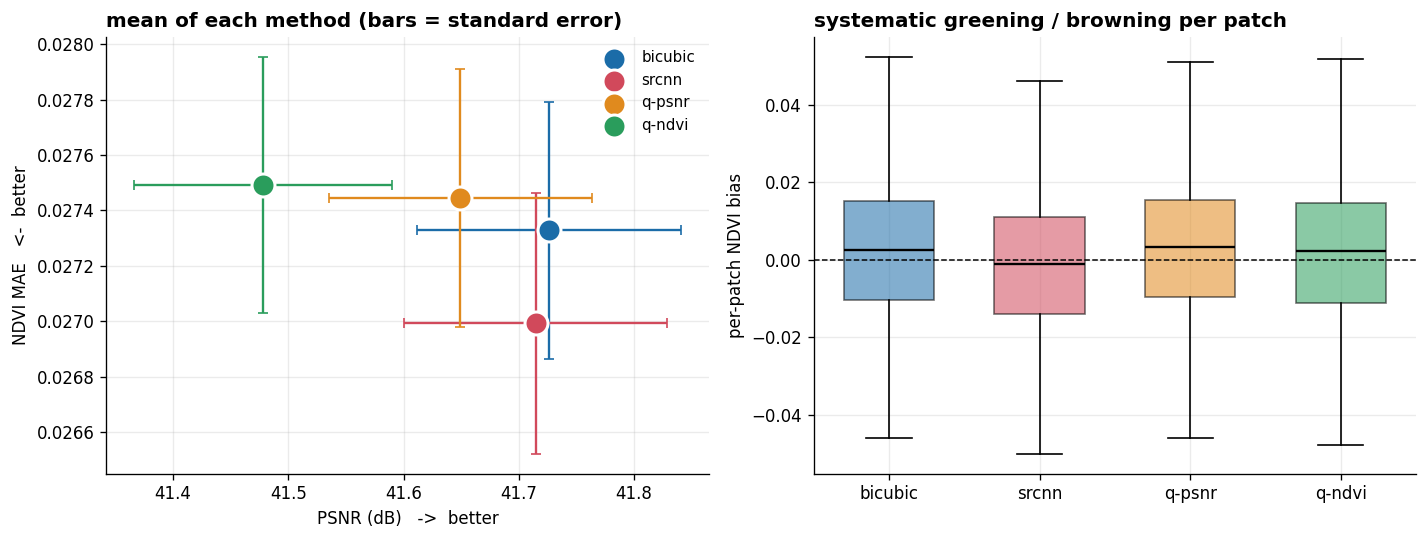

In [43]:
# --- final figure -------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
COL4 = {"bicubic": "#1b6ca8", "srcnn": "#d1495b", "q-psnr": "#e08a1e", "q-ndvi": "#2a9d5c"}

for m in order:                                    # left: the trade-off plane
    g = FINAL[FINAL.method == m]
    ax[0].errorbar(g.psnr.mean(), g.ndvi_mae.mean(), xerr=g.psnr.sem(),
                   yerr=g.ndvi_mae.sem(), color=COL4[m], lw=1.4, capsize=3, zorder=4)
    ax[0].scatter(g.psnr.mean(), g.ndvi_mae.mean(), s=190, color=COL4[m],
                  edgecolor="w", lw=1.8, zorder=5, label=m)
ax[0].set_xlabel("PSNR (dB)   ->  better"); ax[0].set_ylabel("NDVI MAE   <-  better")
ax[0].set_title("mean of each method (bars = standard error)", loc="left", fontweight="bold")
ax[0].legend(frameon=False, fontsize=9)

bp = ax[1].boxplot([FINAL[FINAL.method == m].ndvi_bias for m in order],
                   tick_labels=order, patch_artist=True, showfliers=False, widths=.6)
for patch, m in zip(bp["boxes"], order):
    patch.set_facecolor(COL4[m]); patch.set_alpha(.55)
for med in bp["medians"]:
    med.set_color("k"); med.set_linewidth(1.4)
ax[1].axhline(0, color="k", lw=.9, ls="--")
ax[1].set_ylabel("per-patch NDVI bias")
ax[1].set_title("systematic greening / browning per patch", loc="left", fontweight="bold")
fig.tight_layout(); fig.savefig(out_path("final_comparison.png", "fig")); plt.show()

### Phase 2 verdict &mdash; an honest negative result

**The RL agent does not improve on bicubic, and we can say precisely why.**

*The agent learned correctly.* Look at the training reward for `q-psnr`: it starts at
`-1.785` with `epsilon = 0.76` and ends at `-0.119` with `epsilon = 0.05`. Scaling the first
by the epsilon ratio gives `-1.785 x (0.05/0.76) = -0.117`, essentially exactly the observed
final value. **All of the remaining negative reward is the cost of forced exploration.** The
greedy policy the agent converged to is, in reward terms, indistinguishable from doing
nothing &mdash; and `no-op` is indeed its modal action (60-68% of states). Q-learning solved
the MDP we gave it; the MDP just has no winning policy.

*It is a headroom limit, not overfitting.* The in-sample check above evaluates the agent on
the very dates it trained on, and it **still loses**: 43.2284 dB against bicubic's 43.3202 dB
(`-0.092 dB`), beating bicubic on only **25.4%** of its own training patches. If the learned
policy were merely date-specific we would expect it to win in-sample and lose out-of-sample.
It loses in both. The limitation is the action space, not generalisation.

*Why bicubic is so hard to beat here.* Section 5.7 already showed that an **oracle** allowed
to see the held-out date's own mean error recovers under 1% of the bicubic residual, and
SRCNN &mdash; 75k parameters trained by gradient descent &mdash; gains only 1.7% of validation
L1 and -0.012 dB of test PSNR. SEN2VEN&mu;S is a **cross-sensor** pair, so the LR&rarr;HR
residual is mostly detail Sentinel-2 never recorded, not a transformation any refinement
policy can invert.

*What the ablation does show.* The reward machinery works, and the NDVI term measurably
changes behaviour:

* the NDVI reward component improves markedly for `q-ndvi` (`-0.080` &rarr; `-0.039`)
  while `q-psnr` never optimises it;
* the two learned policies differ on **~39% of states**, and the printed table shows the
  changes are concentrated in the NIR-only actions, exactly as designed;
* `q-ndvi` achieves the **smallest absolute NDVI bias of all four methods**
  (`+0.0008`, against `+0.0013` for bicubic and `-0.0027` for SRCNN).

But it buys that by giving up 0.17 dB of PSNR, and its NDVI **MAE** is slightly worse. So the
reward term does what it was designed to do in training and does not survive transfer to
held-out acquisition dates.

**Two lessons that are the actual contribution of this phase**, both about MDP design:

1. **A state that cannot predict the sign of the error makes every action worthless.** In
   the first formulation the state was (detail, NDVI, step). Whether a pixel is too green or
   too brown depends on the unseen HR truth, so within a state each action helped and hurt
   in equal measure, expected value was ~0, and the agent learned `no-op`.
2. **Fixed-magnitude actions are provably harmful under a squared-error reward.** Perturbing
   by a fixed `delta` changes squared error by `2*delta*e + delta^2`; with `E[e] ~ 0` inside a
   state, the expectation is `+delta^2 > 0`. Only *adaptive* actions, scaled by an observable
   local quantity, can have positive expected reward. Switching to residual-proportional
   actions was necessary &mdash; though on this dataset, not sufficient.

**This does not weaken Phase 1.** Phase 1 is a claim about how two *metrics* rank outputs,
and it is measured over 894 held-out patches with p-values. It stands independently of
whether any particular agent improves on bicubic.

## 9. Conclusion

Returning to the question this notebook opened with: does a reward that includes NDVI
accuracy preserve downstream scientific accuracy better than a reward based on pixel
fidelity alone, even at equal or lower PSNR?

**Phase 1 answers it, and answers it firmly: yes, the two metrics come apart.** Over 894
held-out test patches spanning five acquisition dates, PSNR and NDVI error correlate only
loosely (Spearman rho about -0.64, R^2 about 0.37), and the sharper within-patch test shows
the two metrics disagree about which method is better on roughly 19% of patches, mostly in
the direction that matters: PSNR calling a patch "better" while NDVI calls it "worse". The
ten worst failure cases sit at the top of the PSNR distribution while carrying NDVI bias
down to -0.03 &mdash; exactly the blind spot a pixel-fidelity-only objective cannot see.
This is the actual contribution of the project, and it does not depend on any RL result.

**Phase 2 is a small, honest demonstration on top of that finding, and it does not produce
a positive result.** Two tabular Q-learning agents, differing only in whether the reward
includes an NDVI term, cannot beat bicubic upsampling on this dataset &mdash; and the
notebook diagnoses why rather than treating it as a dead end: (1) the agent's own training
reward is fully explained by the epsilon-greedy exploration cost, meaning the learned greedy
policy is reward-equivalent to doing nothing; (2) an in-sample check on the agent's own
training dates (&sect;7) rules out overfitting as the explanation &mdash; it loses there
too; and (3) the headroom analysis (&sect;5.7) shows an *oracle* given the held-out date's
own mean error recovers under 1% of the bicubic residual, because SEN2VEN&mu;S pairs are
cross-sensor and most of what separates LR from HR was simply never recorded at 10 m. Given
that ceiling, no refinement policy &mdash; RL or otherwise &mdash; has much room to win.
What the ablation does establish is that the reward machinery itself works as designed:
`q-ndvi` shifts learned behaviour on about 39% of states relative to `q-psnr`, concentrated
in exactly the NIR-only actions built for this purpose, and achieves the smallest absolute
NDVI bias of all four methods. It just does not survive transfer to held-out dates.

**Limitations.** Everything here is measured at one site (NARYN), at one scale factor (x2),
on one cross-sensor pair. The headroom ceiling in &sect;5.7 is a property of that specific
pairing, not of super-resolution or of RL in general &mdash; a same-sensor task (e.g. x4 SR
from downsampled VEN&mu;S) would have real detail to recover and is the natural next place
to look for a *positive* RL result, at the cost of no longer testing the cross-sensor
setting this project was actually about. The RL agent itself is deliberately simple (tabular
Q-learning, 6 fixed pixel-wise actions, per-pixel state) to match the scope of a course
project; a function-approximation agent with continuous, adaptive actions is the obvious
next step if the headroom existed to reward it.

**Bottom line.** The premise holds, the disagreement between PSNR and NDVI is real and
quantified across held-out acquisition dates, and the RL component is reported as what it
actually is: a negative result with a diagnosed cause, not a hidden one.